In [1]:
# Optuna hyperparameter summary table (for slides)
import pandas as pd
import optuna
from pathlib import Path

try:
    current_location = Path(__file__).resolve().parent
except NameError:
    current_location = Path.cwd().resolve()

if current_location.name in ["Finalized_Scripts", "Test_Scripts", "scripts"]:
    PROJECT_ROOT = current_location.parent
else:
    PROJECT_ROOT = current_location

db_path = PROJECT_ROOT / "Data_Files" / "floodnet_hpo_newfilter.db"
storage = f"sqlite:///{db_path}"

study_names = ["log_ridge", "res_ann", "attn_lstm"]
rows = []

if not db_path.exists():
    print(f"Optuna DB not found: {db_path}")
else:
    for name in study_names:
        try:
            study = optuna.load_study(study_name=name, storage=storage)
            row = {
                "model": name,
                "best_val_nse": round(float(study.best_value), 4),
                "n_trials": len(study.trials),
            }
            for k, v in study.best_params.items():
                row[k] = v
            rows.append(row)
        except Exception as e:
            rows.append({"model": name, "error": str(e)})

    hpo_params_table = pd.DataFrame(rows)
    display(hpo_params_table)
    # Optional export for slides:
hpo_params_table.to_csv(PROJECT_ROOT / "results" / "hpo_best_params_table.csv", index=False)


/home/dng3fe/floodnet_work/.venv/lib64/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,model,best_val_nse,n_trials,alpha,log_shift,target_transform,use_weighted_loss,loss_lambda,hidden_size,n_layers,lr,dropout,weight_decay,loss_fn,underpredict_penalty,batch_size,window_size
0,log_ridge,0.6098,2000,0.000095,0.115922,log,True,1.478086,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,res_ann,0.8385,1311,NaN,NaN,NaN,False,6.186041,896.0,2.0,0.000171,0.102095,0.000023,huber,5.200854,16384.0,NaN
2,attn_lstm,0.7742,1000,NaN,NaN,NaN,False,4.549848,160.0,3.0,0.000386,0.017717,0.000011,huber,7.912309,2048.0,30.0


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import optuna
from sklearn.linear_model import LinearRegression
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
import folium
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from pathlib import Path

In [3]:
# 1. Identify the current directory (Handles both .py scripts and Jupyter)
try:
    # Use __file__ for standalone scripts
    current_location = Path(__file__).resolve().parent
except NameError:
    # Use Current Working Directory for Jupyter/Interactive sessions
    current_location = Path.cwd().resolve()

# 2. Navigate to the actual Project Root
# If current_location is 'Finalized_Scripts', move to the parent directory
if current_location.name in ["Finalized_Scripts", "Test_Scripts", "scripts"]:
    PROJECT_ROOT = current_location.parent
else:
    PROJECT_ROOT = current_location

# 3. Define the absolute path to the data
# This ensures the path is /floodnet_work/Data_Files/ instead of /Finalized_Scripts/Data_Files/
data_dir = PROJECT_ROOT / "Data_Files"
file_name = "apparently-darling-gecko.parquet"
file_path = data_dir / file_name

# 4. Safety Check and Data Loading
if not file_path.exists():
    # This will print the exact path being searched to help with troubleshooting
    raise FileNotFoundError(f"Target file not found at: {file_path}")

df_storms = pd.read_parquet(file_path)

print(f"Successfully loaded data from: {file_path}")

Successfully loaded data from: /sfs/gpfs/tardis/home/dng3fe/floodnet_work/Data_Files/apparently-darling-gecko.parquet


In [4]:
# Convert time to datetime if not already
df_storms['time'] = pd.to_datetime(df_storms['time'])

# Downcast floats to save 50% RAM for EDA [cite: 14, 15]
for col in df_storms.select_dtypes(include=['float64']).columns:
    df_storms[col] = df_storms[col].astype('float32')

print(f"✅ Data Loaded: {len(df_storms):,} rows.")
print(f"Current Memory Usage: {df_storms.memory_usage().sum() / 1024**2:.2f} MB")

✅ Data Loaded: 38,875 rows.
Current Memory Usage: 17.56 MB


In [5]:
df_storms.columns

Index(['deployment_id', 'time', 'depth_proc_mm', 'depth_inches', 'name',
       'date_deployed', 'date_down', 'deploy_type', 'location', 'image',
       'sensor_mount', 'mounted_over', 'sensor_status', 'coordinates',
       'borough', 'intersection', 'latitude', 'longitude', 'STATION',
       'dist_to_station_ft', 'weather_time', 'elevation [feet]',
       'temp_2m [degF]', 'relative_humidity [percent]', 'dewpoint [degF]',
       'precip_incremental [inch]', 'precip_max_intensity [inch/hour]',
       'precip_1hr [inch]', 'soil_moisture_05cm [m^3/m^3]', 'DATE',
       'minutes_since_weather_update', 'storm_id', 'global_storm_id',
       'storm_start', 'storm_end', 'rain_start', 'rain_end', 'phase',
       'hours_since_rain_start', 'hours_since_storm_start',
       'minutes_since_weather_update_1', 'total_precip_in',
       'peak_intensity_inh', 'intensity_hits_ge_threshold',
       'net_depth_rise_in', 'storm_record_count', 'storm_duration_hr'],
      dtype='str')

In [6]:
df_storms

,deployment_id,time,depth_proc_mm,depth_inches,name,date_deployed,date_down,deploy_type,location,image,...,phase,hours_since_rain_start,hours_since_storm_start,minutes_since_weather_update_1,total_precip_in,peak_intensity_inh,intensity_hits_ge_threshold,net_depth_rise_in,storm_record_count,storm_duration_hr
0,apparently-darling-gecko,2025-05-21 13:01:11.360000+00:00,0.0,0.0,BX - Tibbett Ave/W 234th St,2025-03-27 15:01:00+00:00,NaT,pluvial,"{'coordinates': [-73.90585, 40.88326], 'crs': ...",6dfc6ee7-d2de-45b1-ae96-df7857c7a56f,...,lead,-1.994014,0.005986,NaN,0.199,0.00,0,0.000000,481,8.052776
1,apparently-darling-gecko,2025-05-21 13:02:15.326000+00:00,0.0,0.0,BX - Tibbett Ave/W 234th St,2025-03-27 15:01:00+00:00,NaT,pluvial,"{'coordinates': [-73.90585, 40.88326], 'crs': ...",6dfc6ee7-d2de-45b1-ae96-df7857c7a56f,...,lead,-1.976245,0.023755,NaN,0.199,0.00,0,0.000000,481,8.052776
2,apparently-darling-gecko,2025-05-21 13:03:19.291000+00:00,0.0,0.0,BX - Tibbett Ave/W 234th St,2025-03-27 15:01:00+00:00,NaT,pluvial,"{'coordinates': [-73.90585, 40.88326], 'crs': ...",6dfc6ee7-d2de-45b1-ae96-df7857c7a56f,...,lead,-1.958477,0.041523,NaN,0.199,0.00,0,0.000000,481,8.052776
3,apparently-darling-gecko,2025-05-21 13:04:23.257000+00:00,0.0,0.0,BX - Tibbett Ave/W 234th St,2025-03-27 15:01:00+00:00,NaT,pluvial,"{'coordinates': [-73.90585, 40.88326], 'crs': ...",6dfc6ee7-d2de-45b1-ae96-df7857c7a56f,...,lead,-1.940709,0.059291,NaN,0.199,0.00,0,0.000000,481,8.052776
4,apparently-darling-gecko,2025-05-21 13:05:27.222000+00:00,0.0,0.0,BX - Tibbett Ave/W 234th St,2025-03-27 15:01:00+00:00,NaT,pluvial,"{'coordinates': [-73.90585, 40.88326], 'crs': ...",6dfc6ee7-d2de-45b1-ae96-df7857c7a56f,...,lead,-1.922941,0.077059,NaN,0.199,0.00,0,0.000000,481,8.052776
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38870,apparently-darling-gecko,2026-03-12 10:58:01.914000+00:00,0.0,0.0,BX - Tibbett Ave/W 234th St,2025-03-27 15:01:00+00:00,NaT,pluvial,"{'coordinates': [-73.90585, 40.88326], 'crs': ...",6dfc6ee7-d2de-45b1-ae96-df7857c7a56f,...,lag,8.966380,10.966380,NaN,1.333,3.47,1,1.417323,382,11.066659
38871,apparently-darling-gecko,2026-03-12 11:00:01.937000+00:00,0.0,0.0,BX - Tibbett Ave/W 234th St,2025-03-27 15:01:00+00:00,NaT,pluvial,"{'coordinates': [-73.90585, 40.88326], 'crs': ...",6dfc6ee7-d2de-45b1-ae96-df7857c7a56f,...,lag,8.999720,10.999720,NaN,1.333,3.47,1,1.417323,382,11.066659
38872,apparently-darling-gecko,2026-03-12 11:01:01.898000+00:00,0.0,0.0,BX - Tibbett Ave/W 234th St,2025-03-27 15:01:00+00:00,NaT,pluvial,"{'coordinates': [-73.90585, 40.88326], 'crs': ...",6dfc6ee7-d2de-45b1-ae96-df7857c7a56f,...,lag,9.016376,11.016376,NaN,1.333,3.47,1,1.417323,382,11.066659
38873,apparently-darling-gecko,2026-03-12 11:03:01.921000+00:00,0.0,0.0,BX - Tibbett Ave/W 234th St,2025-03-27 15:01:00+00:00,NaT,pluvial,"{'coordinates': [-73.90585, 40.88326], 'crs': ...",6dfc6ee7-d2de-45b1-ae96-df7857c7a56f,...,lag,9.049716,11.049716,NaN,1.333,3.47,1,1.417323,382,11.066659


In [7]:
import pandas as pd

# 1. Load the raw, unfiltered data
df_raw = pd.read_parquet("/home/dng3fe/floodnet_work/Data_Files/rain_influenced_sites_raw.parquet")

# 2. Double-check the exact spelling (just to be absolutely paranoid)
geckos = [name for name in df_raw['deployment_id'].unique() if 'gecko' in str(name).lower()]
print(f"Gecko variations found: {geckos}")

# 3. Check total raw rows
df_gecko = df_raw[df_raw['deployment_id'] == 'apparently-darling-gecko']
print(f"\nTotal raw rows for this gage: {len(df_gecko)}")

if len(df_gecko) > 0:
    # 4. Funnel 1: The "Wet Record" check
    # The SQL query requires precip >= 0.01 to trigger a storm window
    wet_rows = df_gecko[df_gecko['precip_incremental [inch]'] >= 0.01]
    print(f"Rows with precip >= 0.01: {len(wet_rows)}")
    
    # 5. Funnel 2: Check for missing data in the precipitation column
    print(f"Total NaN values in precip column: {df_gecko['precip_incremental [inch]'].isna().sum()}")

Gecko variations found: ['apparently-darling-gecko']

Total raw rows for this gage: 389086
Rows with precip >= 0.01: 3549
Total NaN values in precip column: 23600


In [8]:
sensor_list = df_storms['deployment_id'].unique().tolist()
print(f"Total Sensors: {len(sensor_list)}")
print("Available IDs:", sensor_list)

Total Sensors: 1
Available IDs: ['apparently-darling-gecko']


In [9]:
df_storms[['latitude', 'longitude']].isna().sum()

latitude     0
longitude    0
dtype: int64

In [10]:
# 1. List all unique sensors
sensor_names = df_storms['deployment_id'].unique().tolist()
print(f"✅ Total unique sensors found: {len(sensor_names)}")
print(f"Sample IDs: {sensor_names[:10]}")

# 2. Create the Spatial Map (NAD83 / New York Long Island Context)
def create_sensor_map(df):
    # Aggregate max depth per sensor for visual scaling
    map_data = df.groupby(['deployment_id', 'latitude', 'longitude'])['depth_inches'].max().reset_index()
    
    # Initialize NYC Map
    m = folium.Map(location=[40.7128, -74.0060], zoom_start=11, tiles='CartoDB Positron')
    
    for _, row in map_data.iterrows():
    # 1. Scale the radius: 1.5 pixels per inch of flood
    # 2. Set a 'floor' of 3 pixels so dry sensors are still visible
    # 3. Use a square root for 'area-based' scaling (more scientifically accurate)
        scaled_radius = row['depth_inches'] * 0.5
    
        folium.CircleMarker(
            location=[row['latitude'], row['longitude']],
            radius=scaled_radius, 
            popup=f"ID: {row['deployment_id']}<br>Max Depth: {row['depth_inches']:.2f} in",
            color='#e74c3c',
            fill=True,
            fill_opacity=0.5,
            weight=1
        ).add_to(m)
    return m

# Display map in Colab
nyc_map = create_sensor_map(df_storms)
nyc_map

✅ Total unique sensors found: 1
Sample IDs: ['apparently-darling-gecko']


🔍 Found 63 discrete storm windows for apparently-darling-gecko.


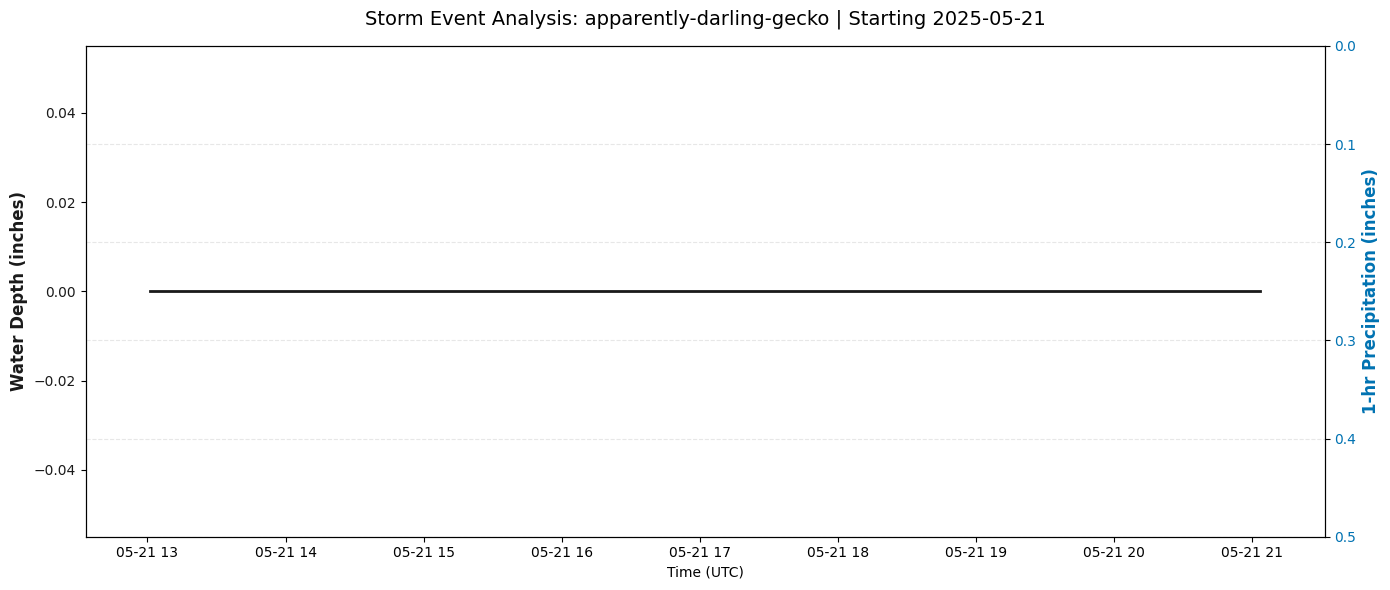

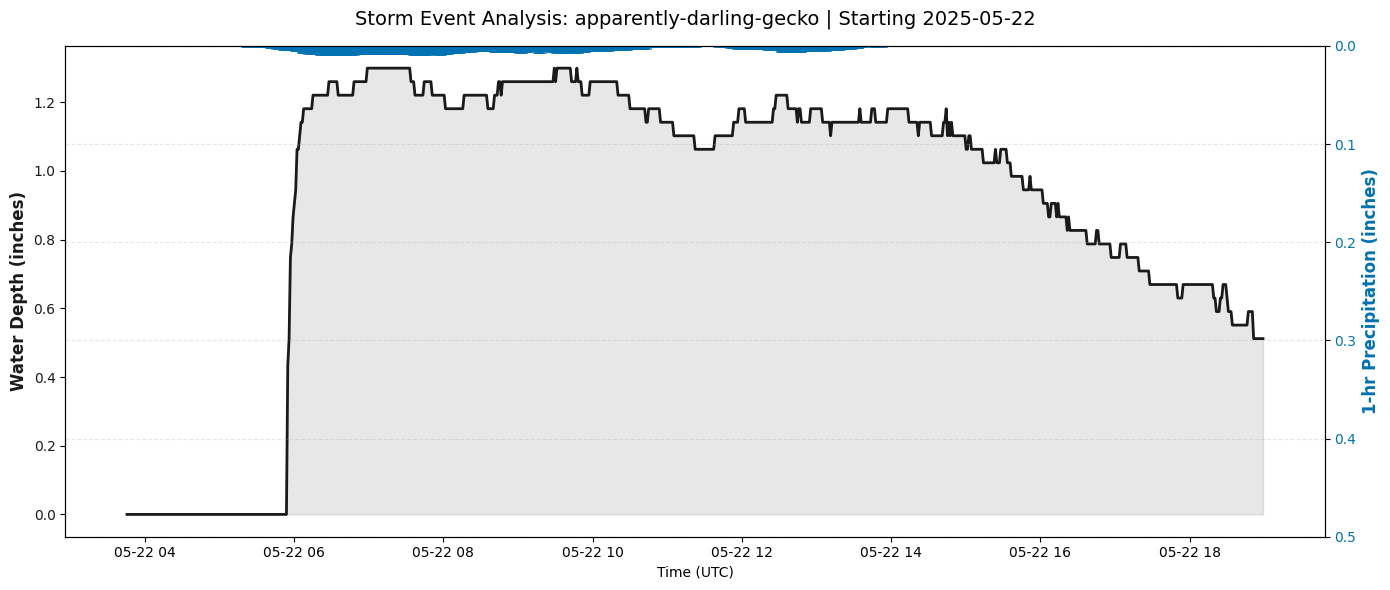

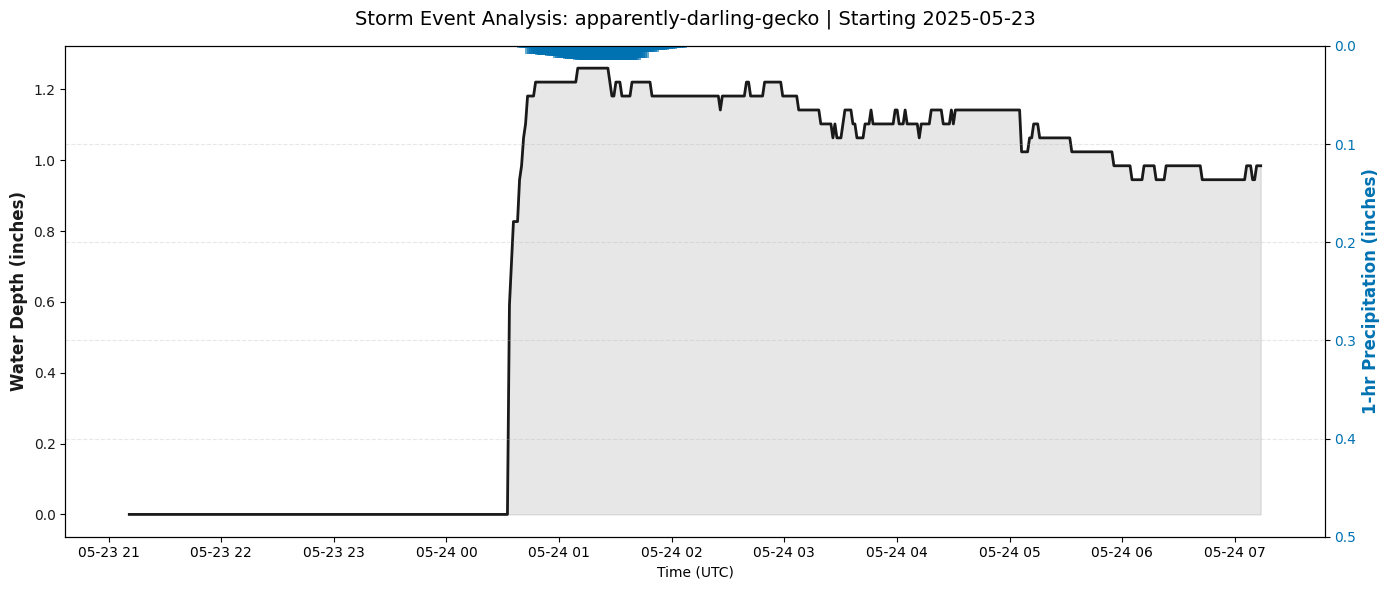

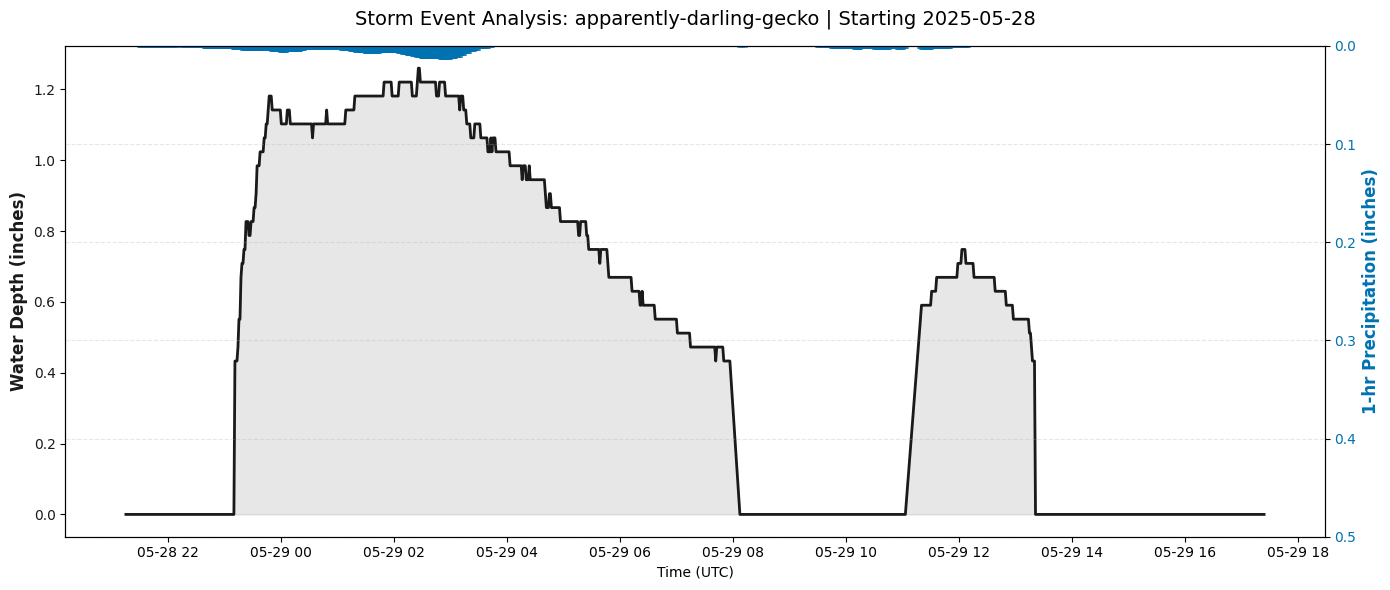

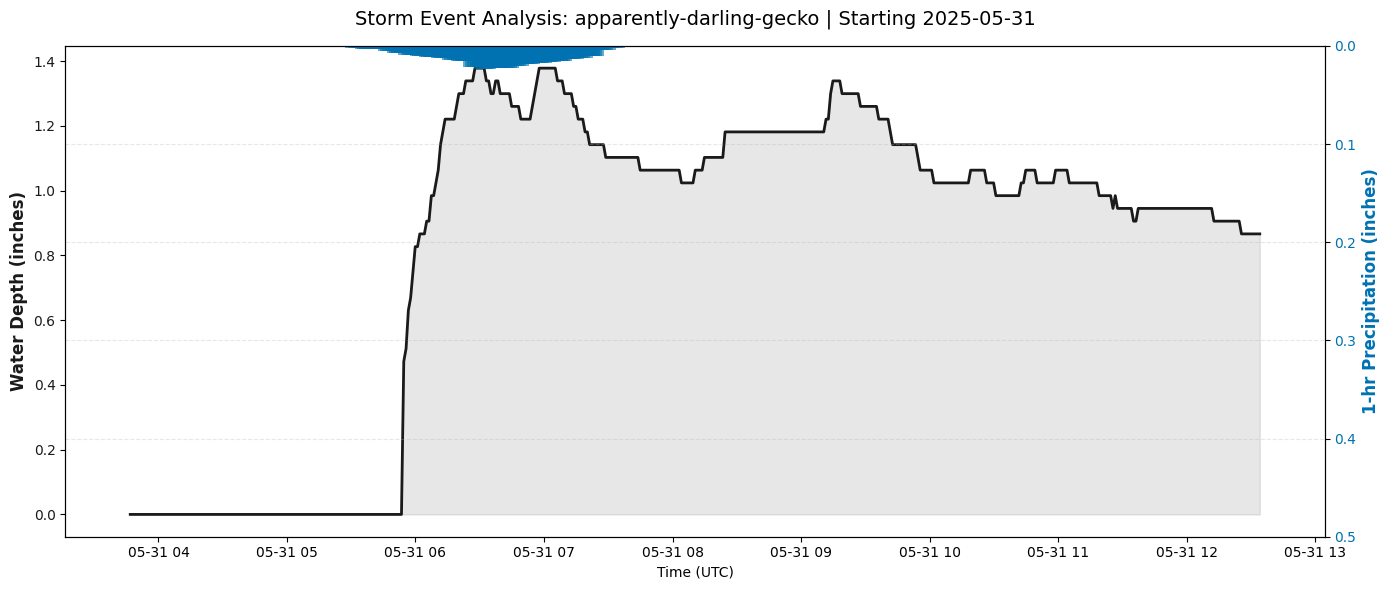

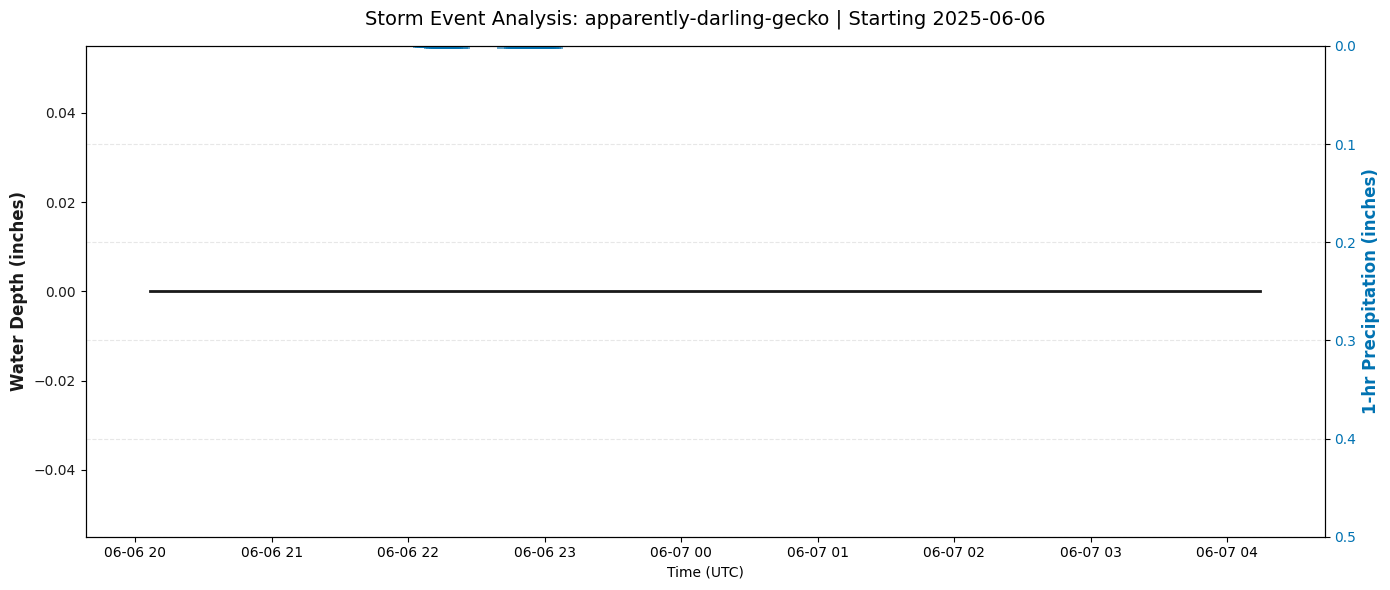

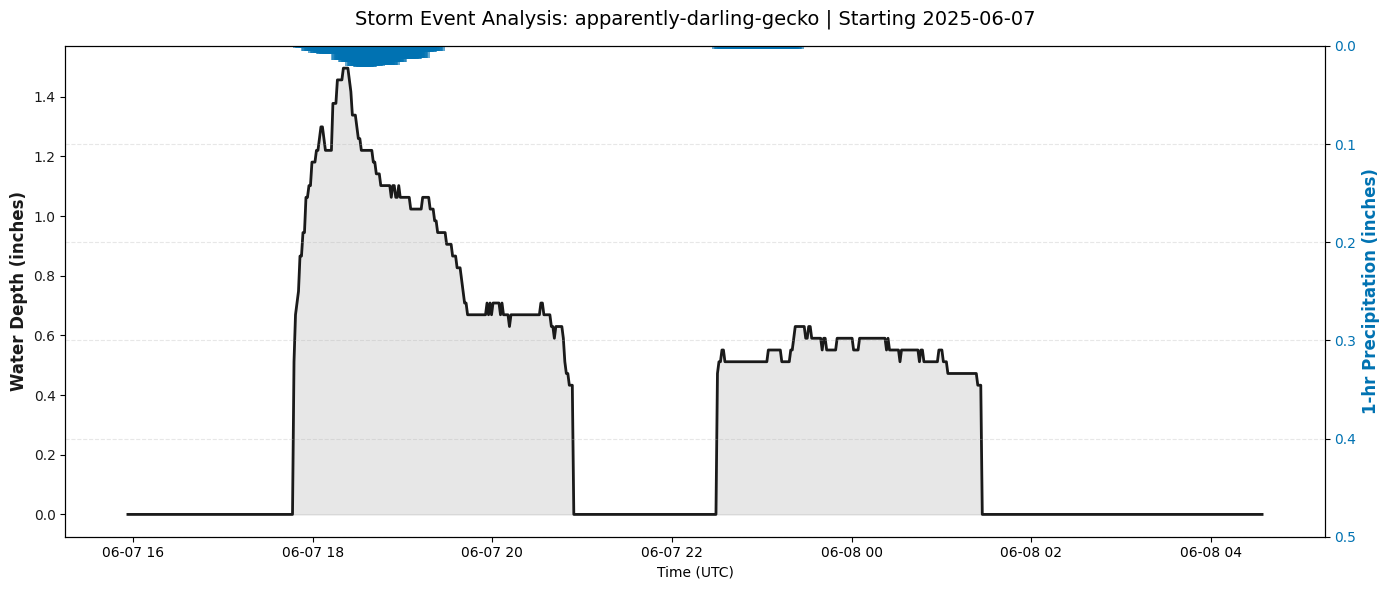

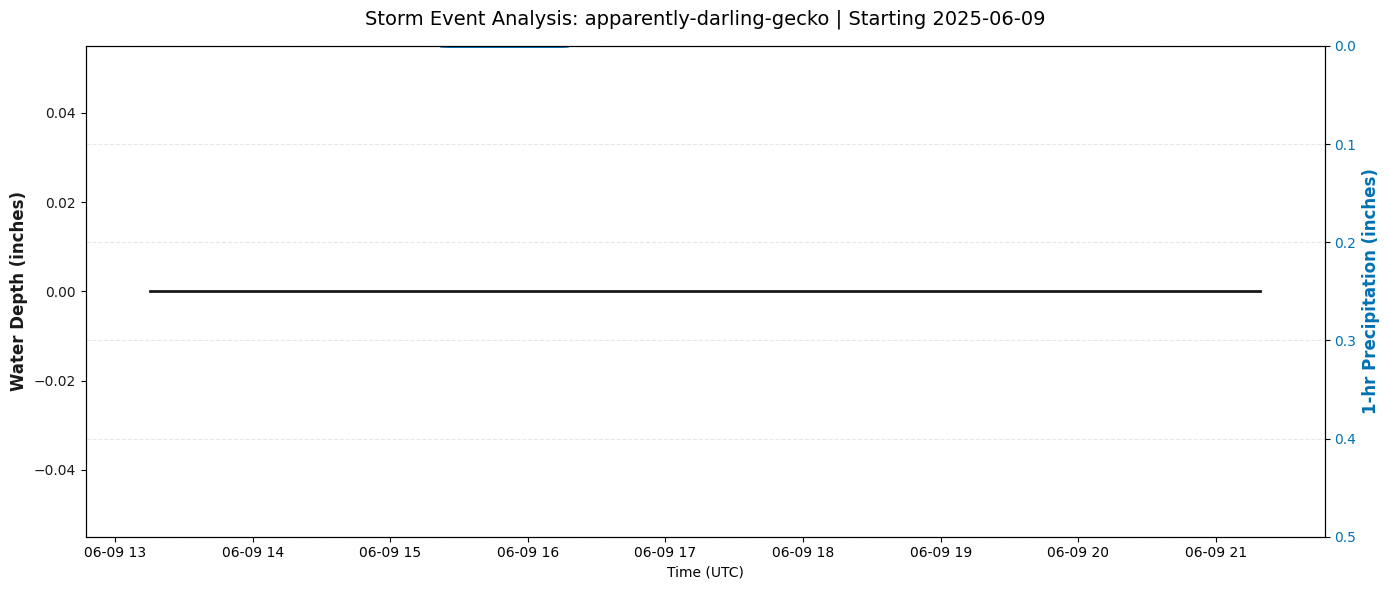

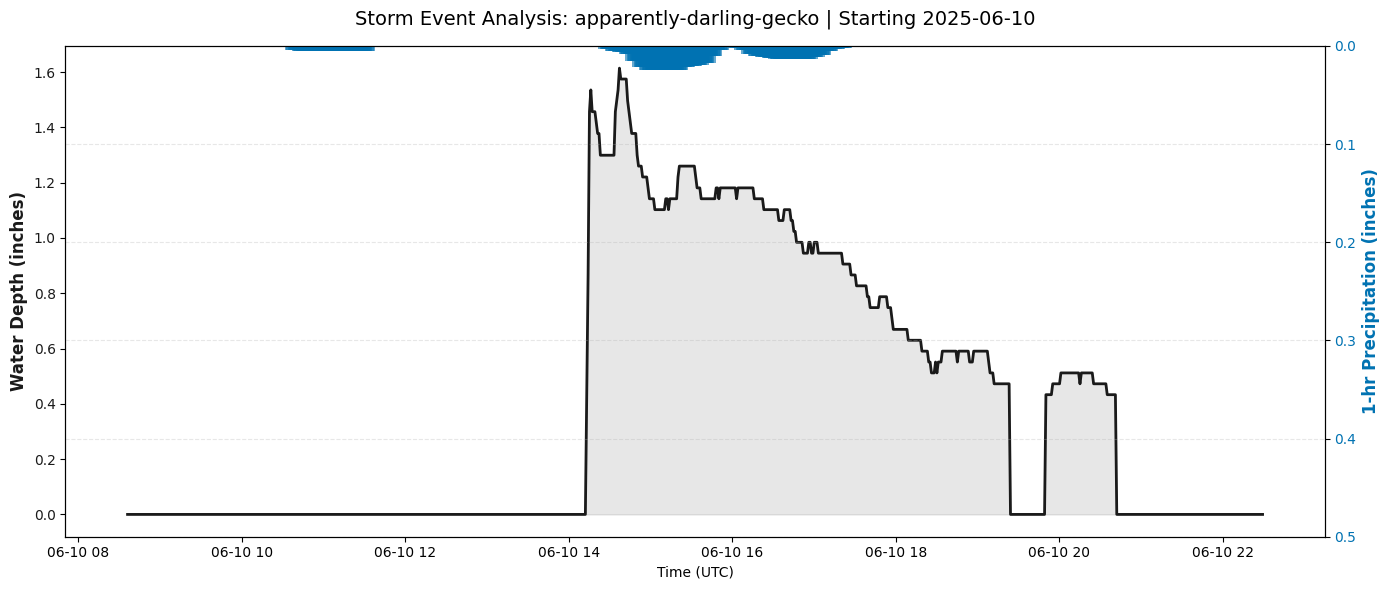

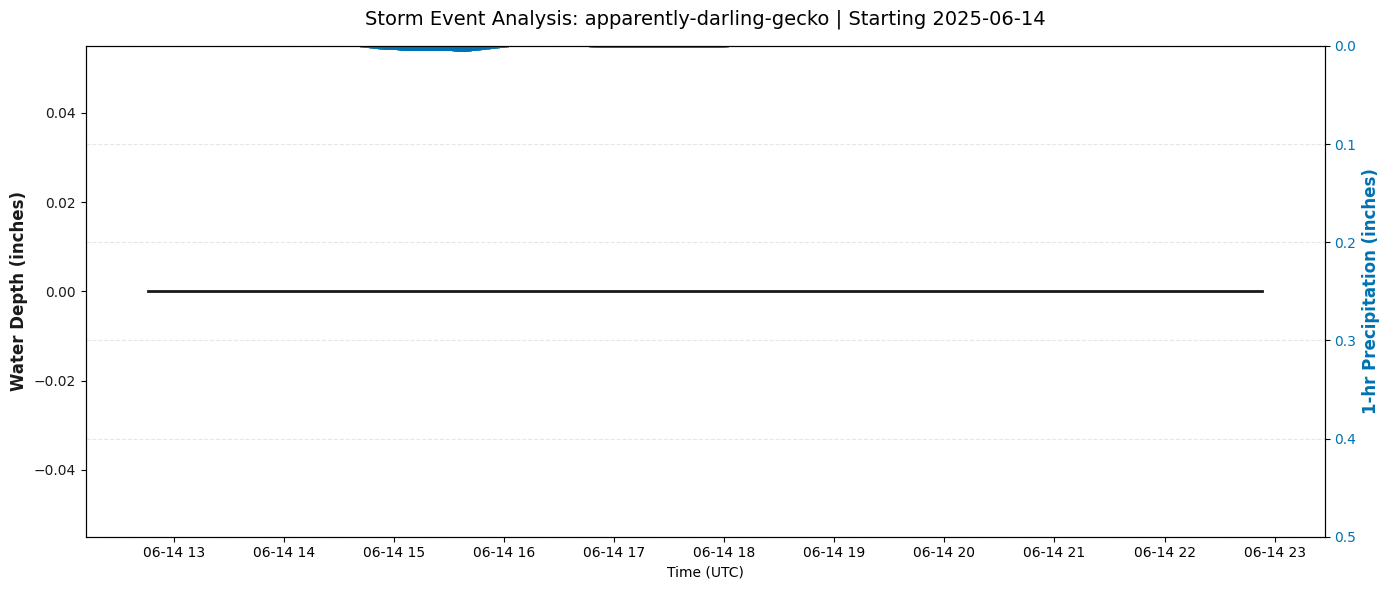

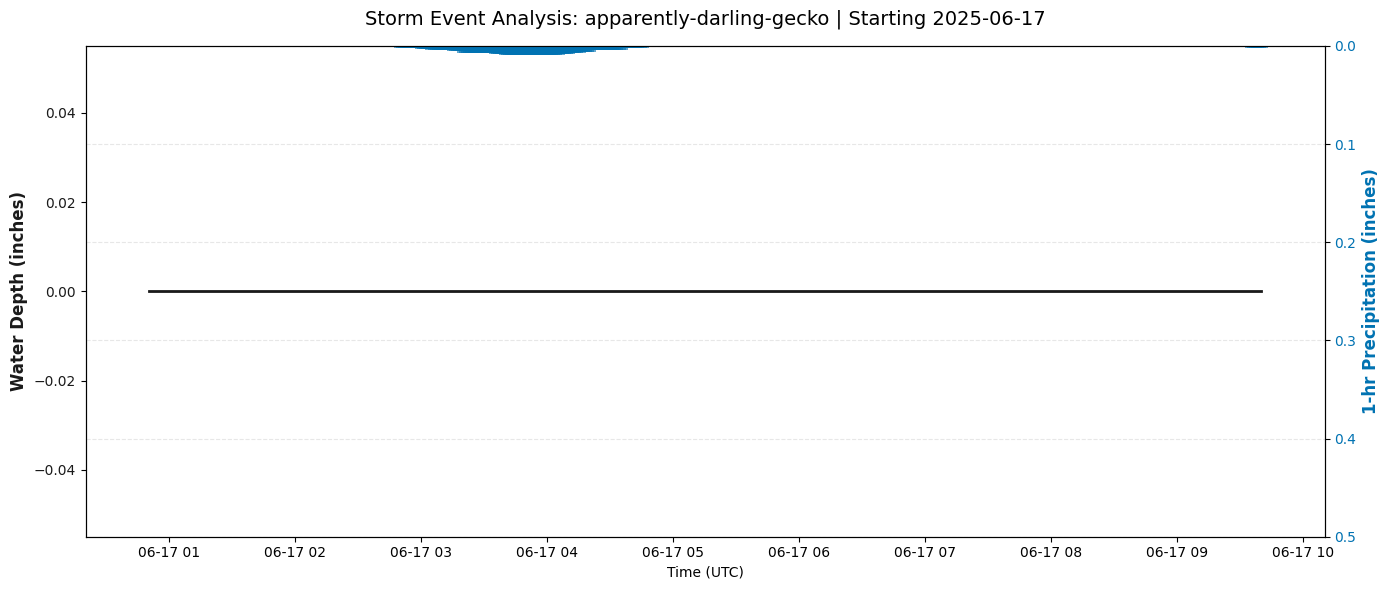

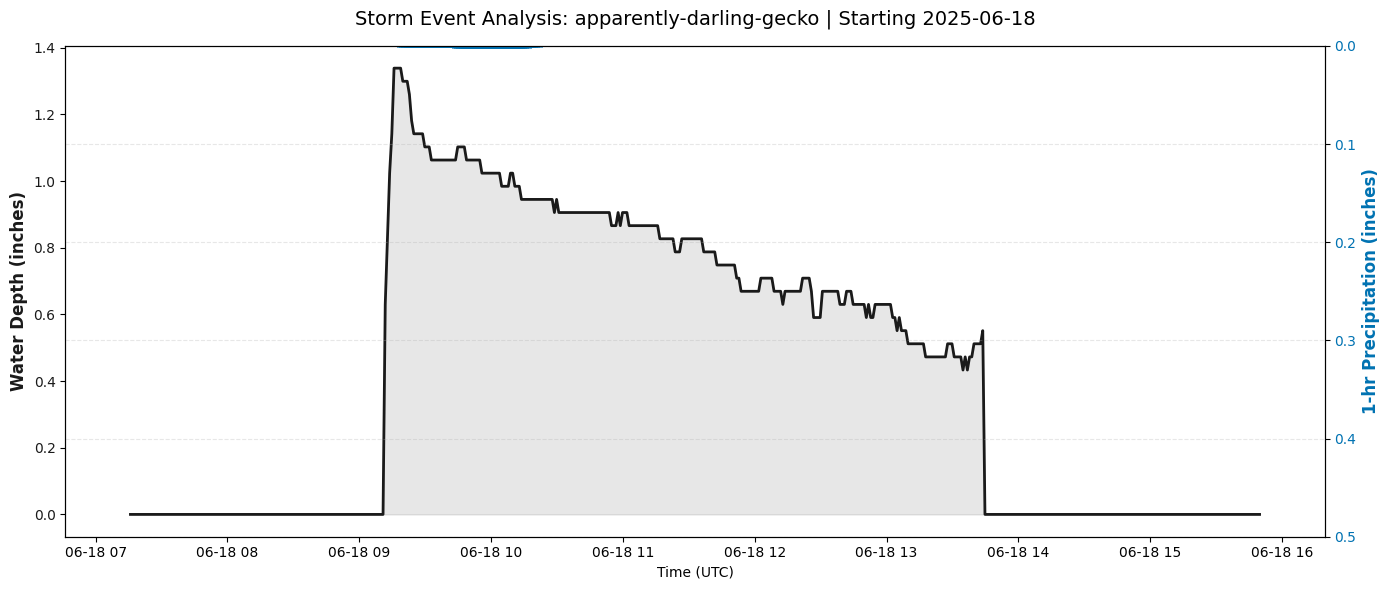

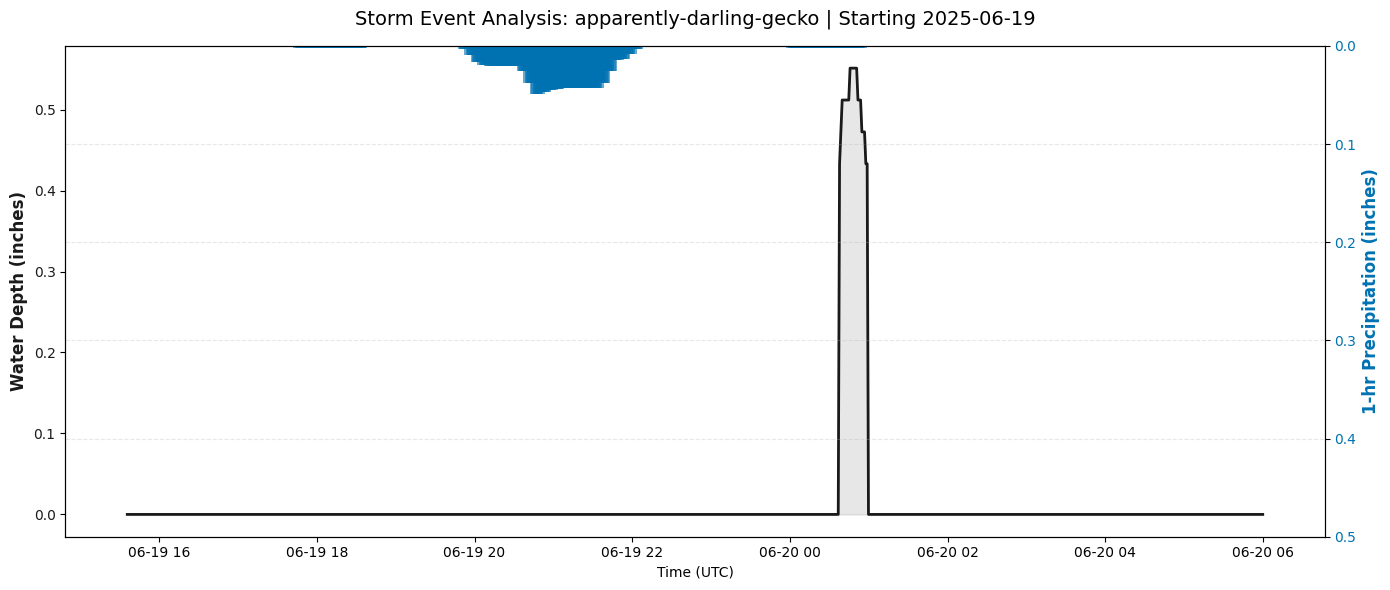

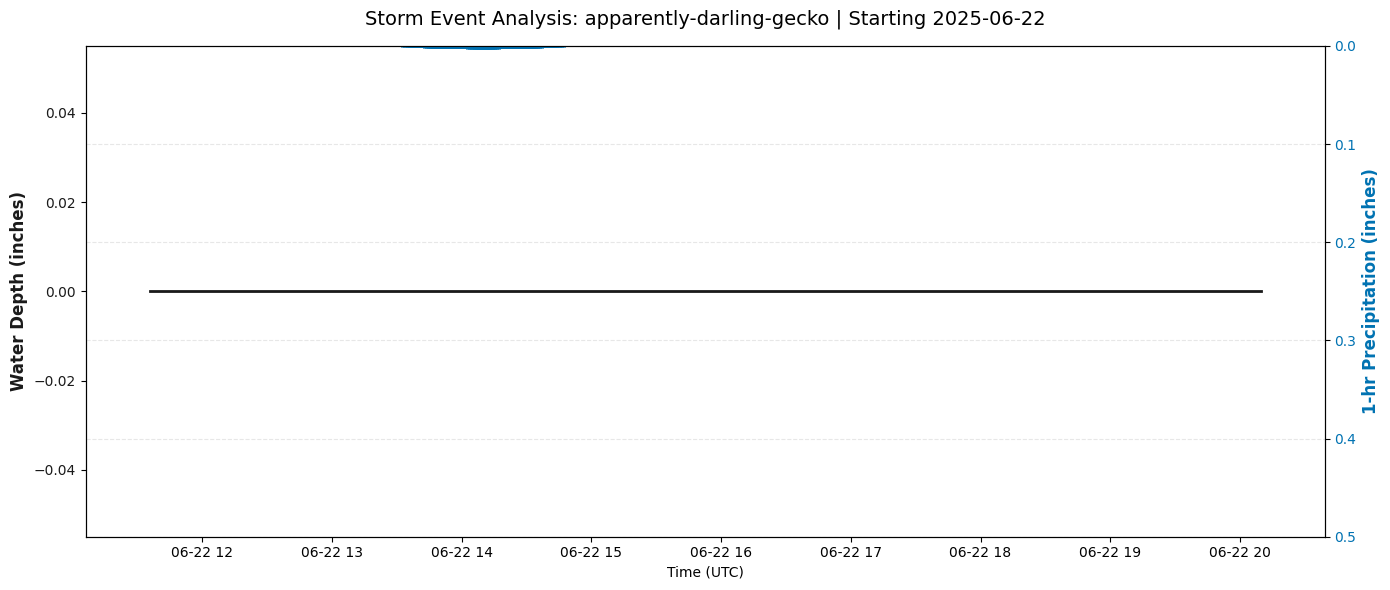

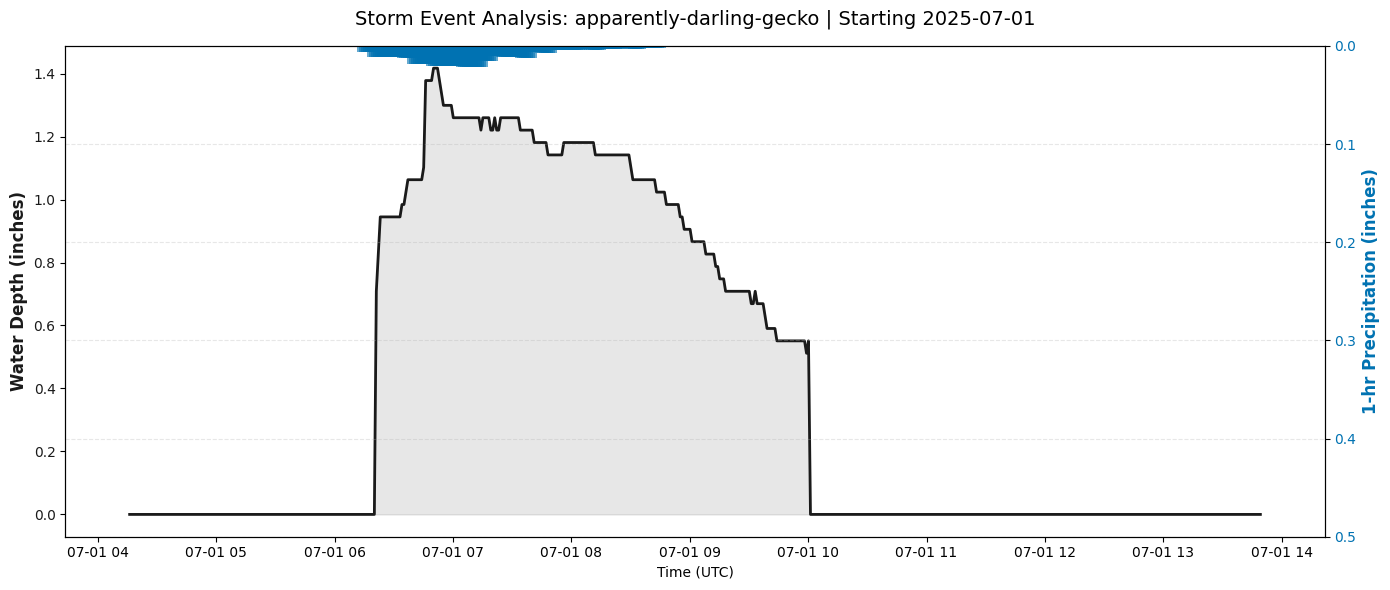

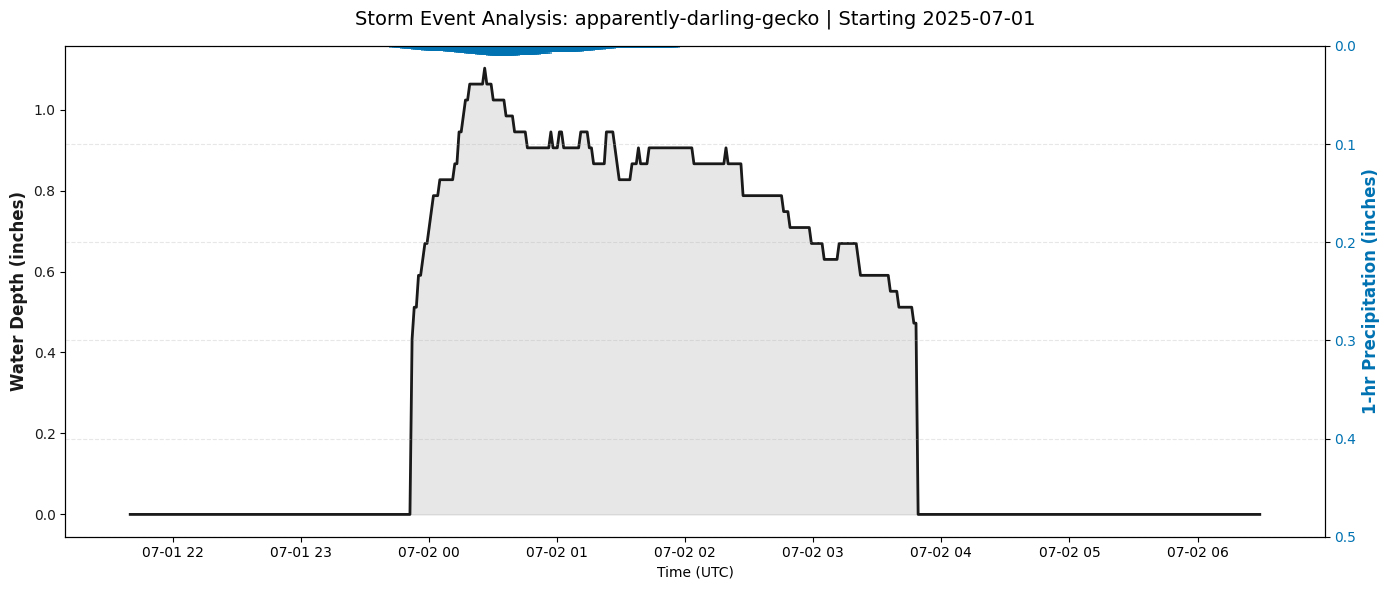

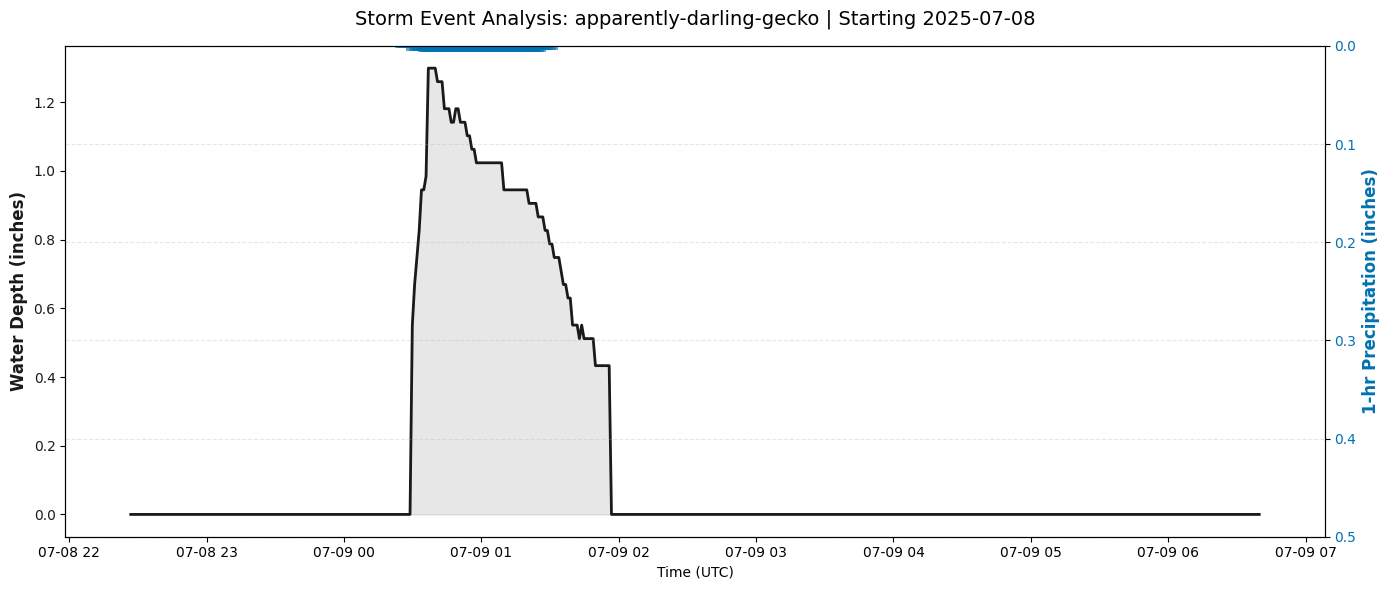

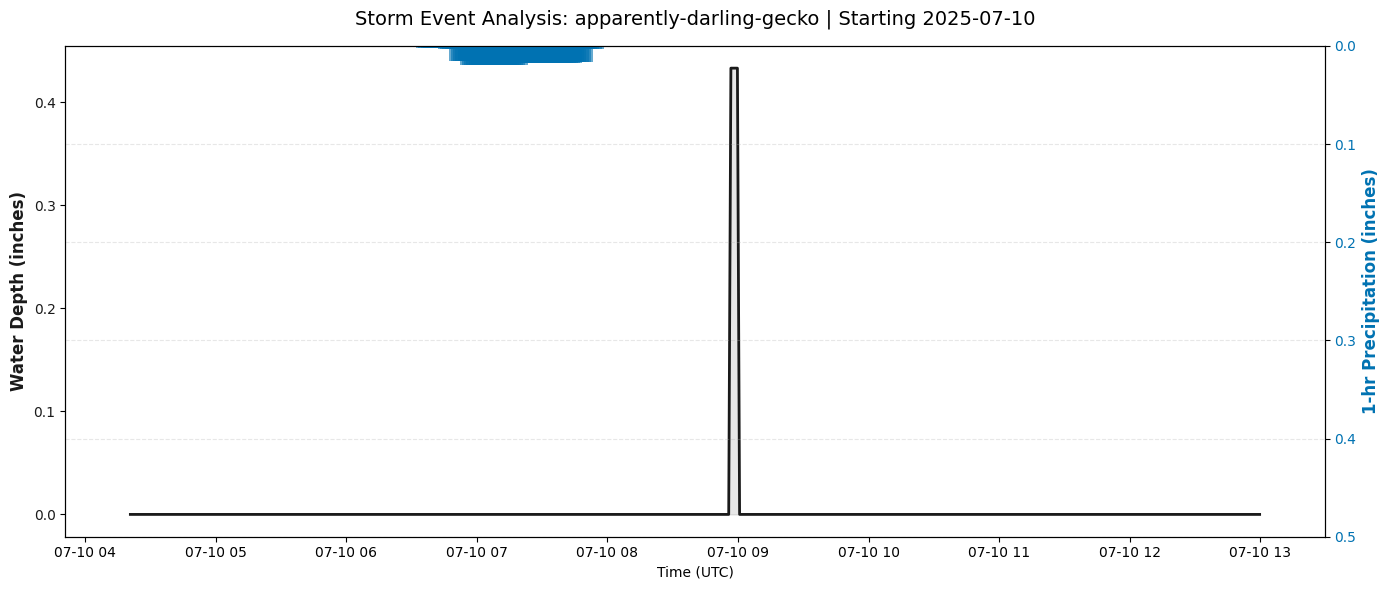

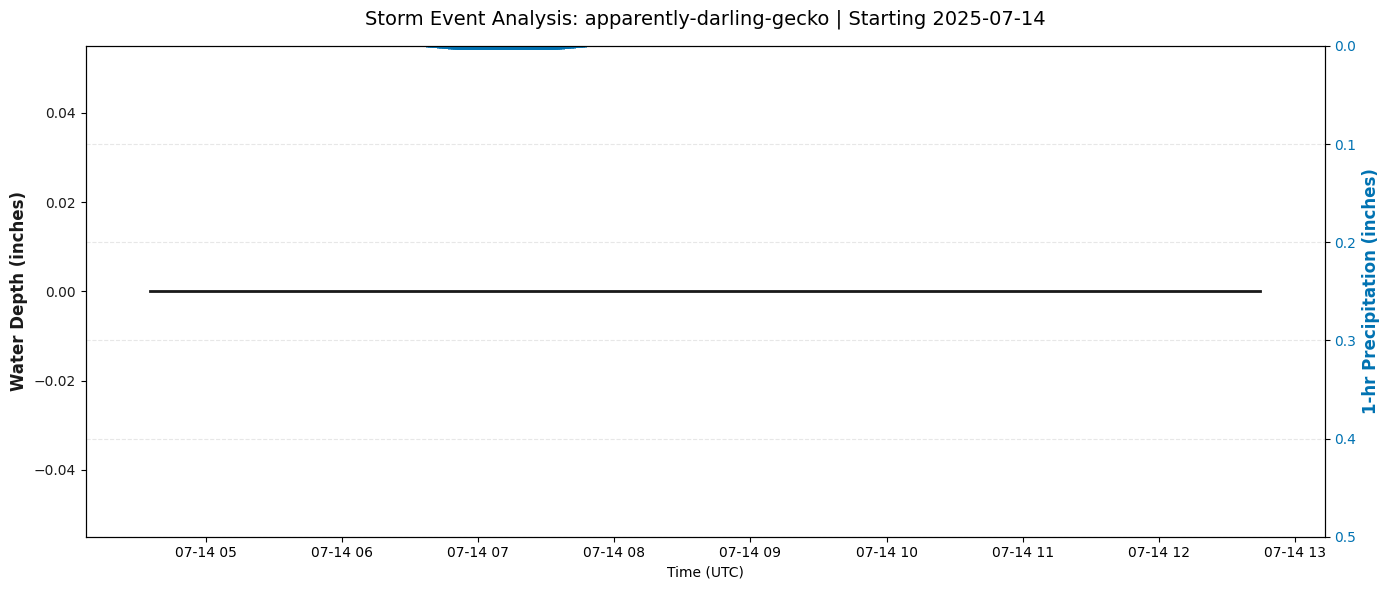

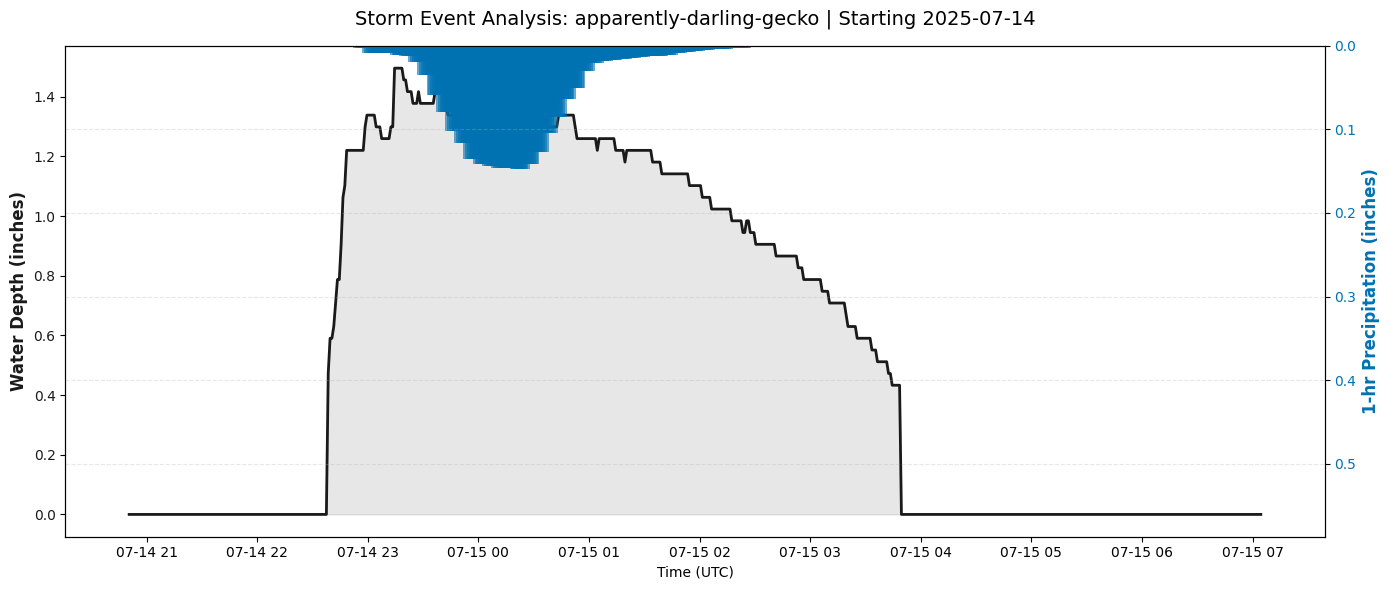

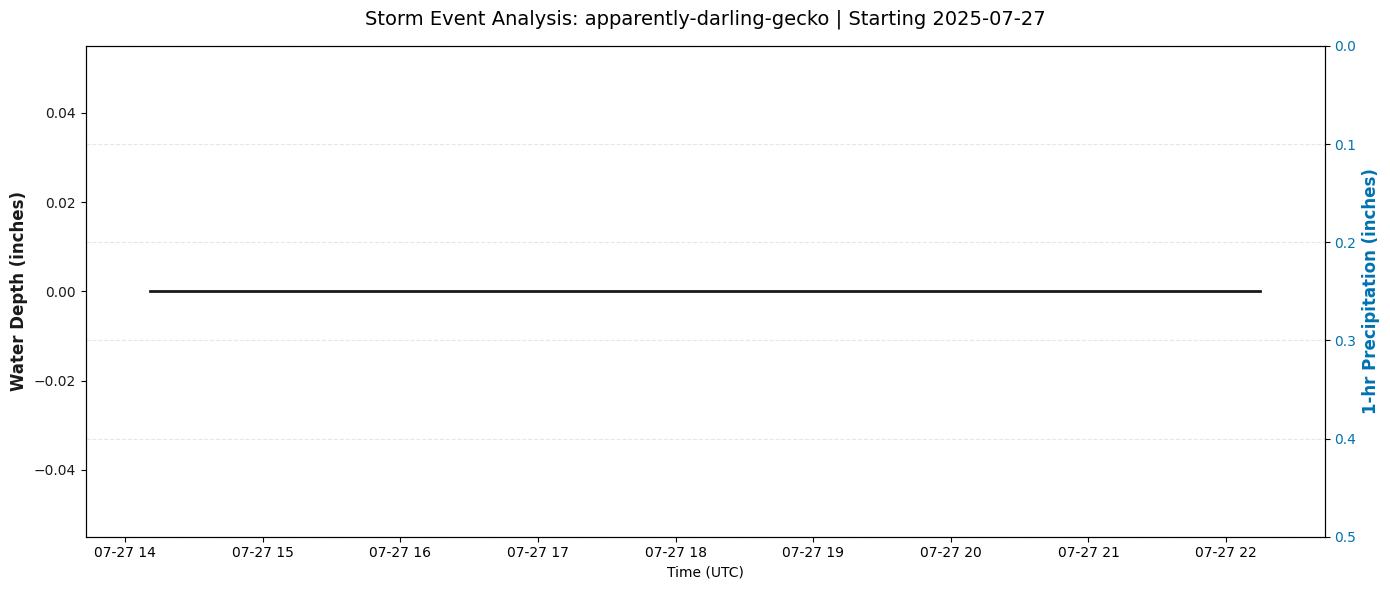

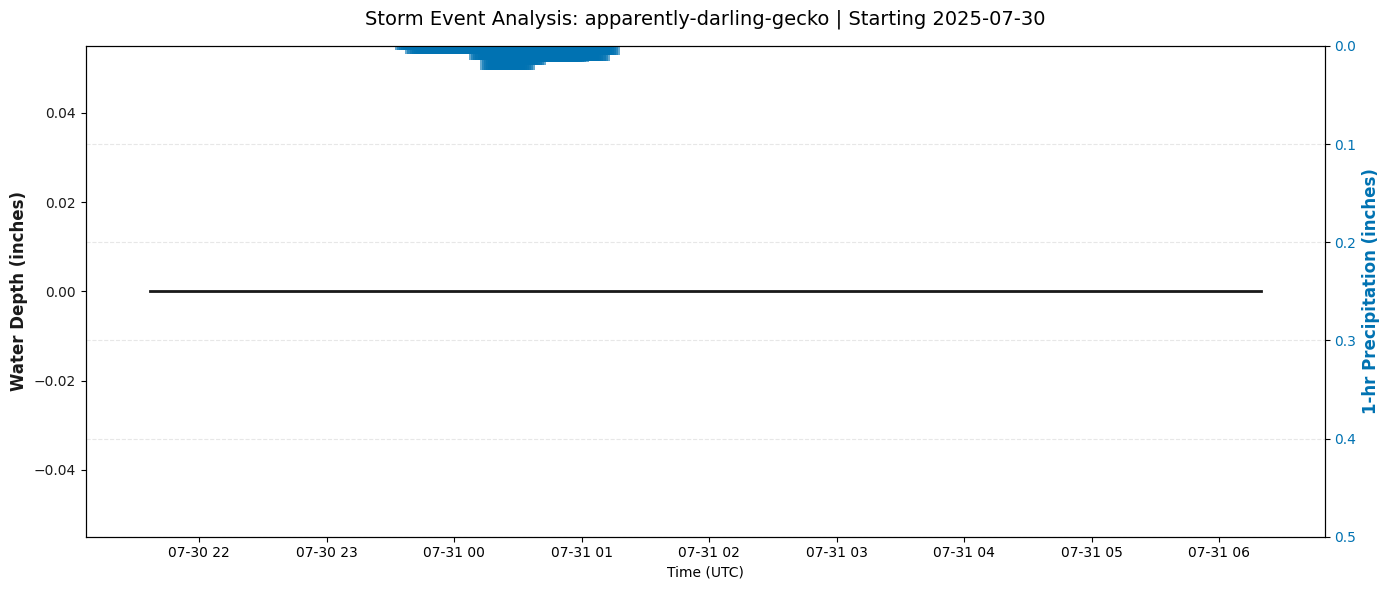

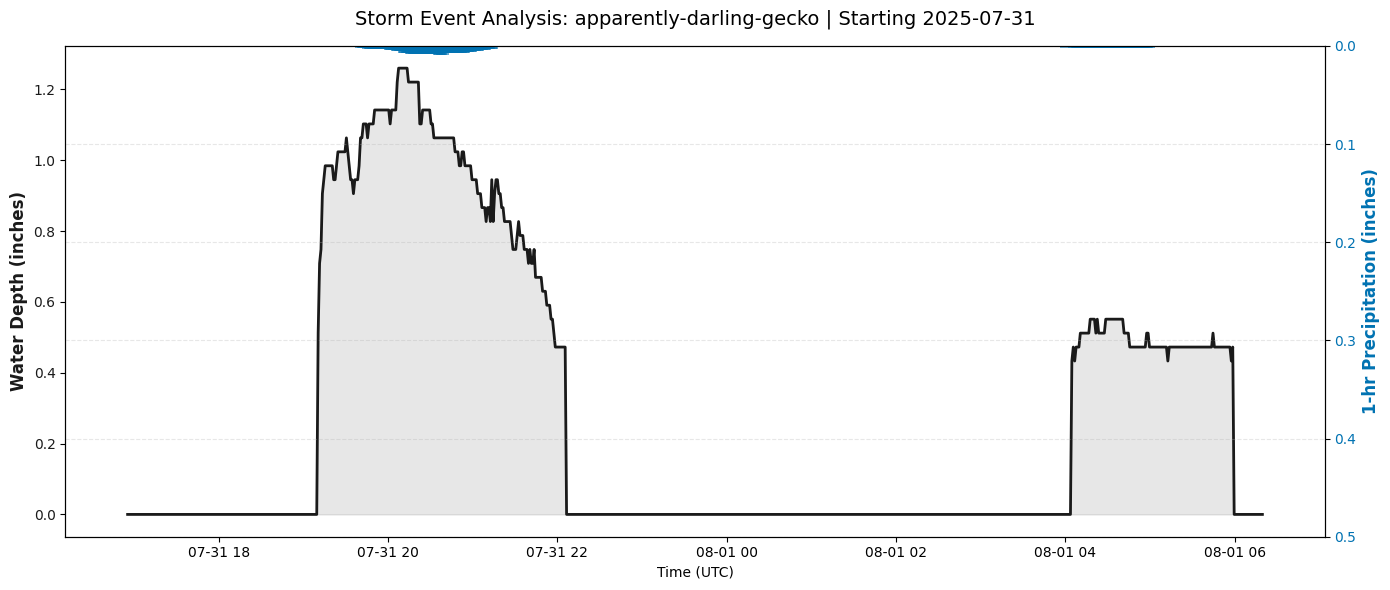

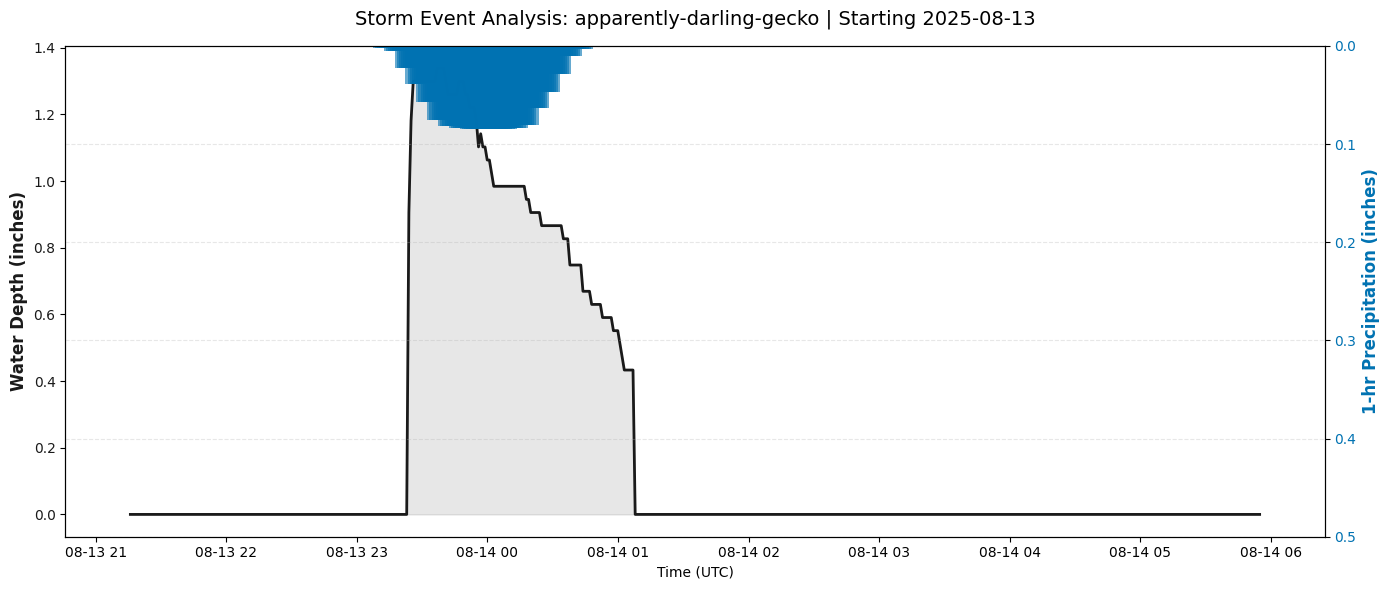

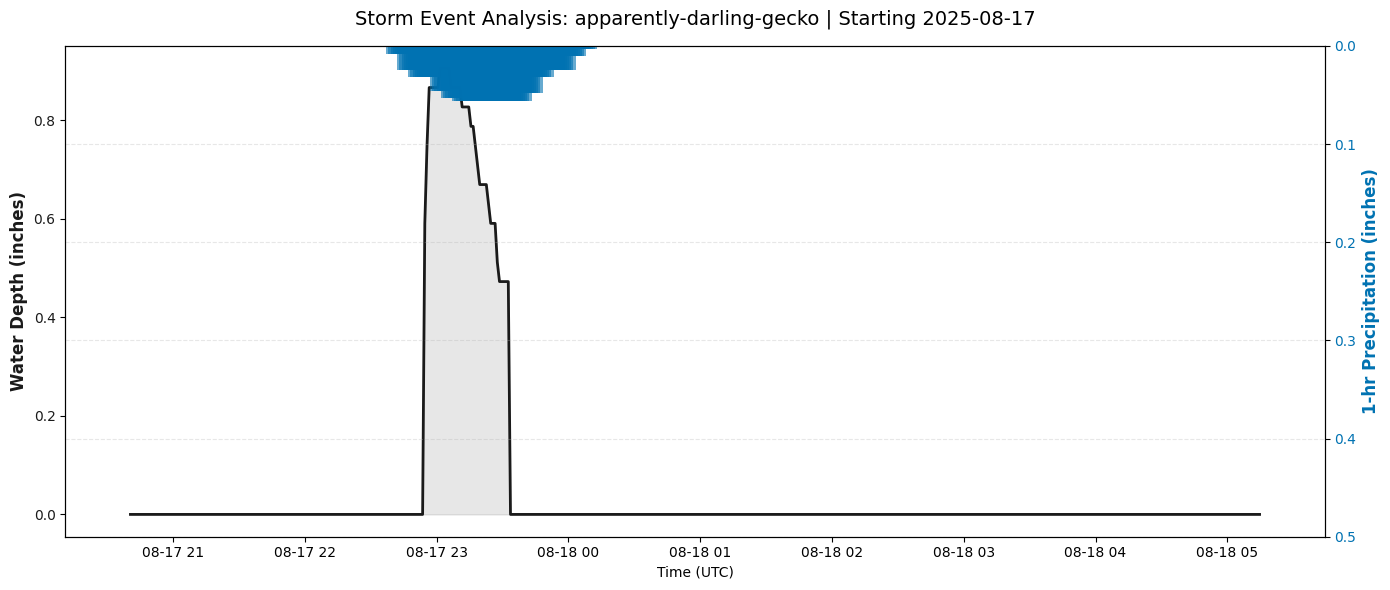

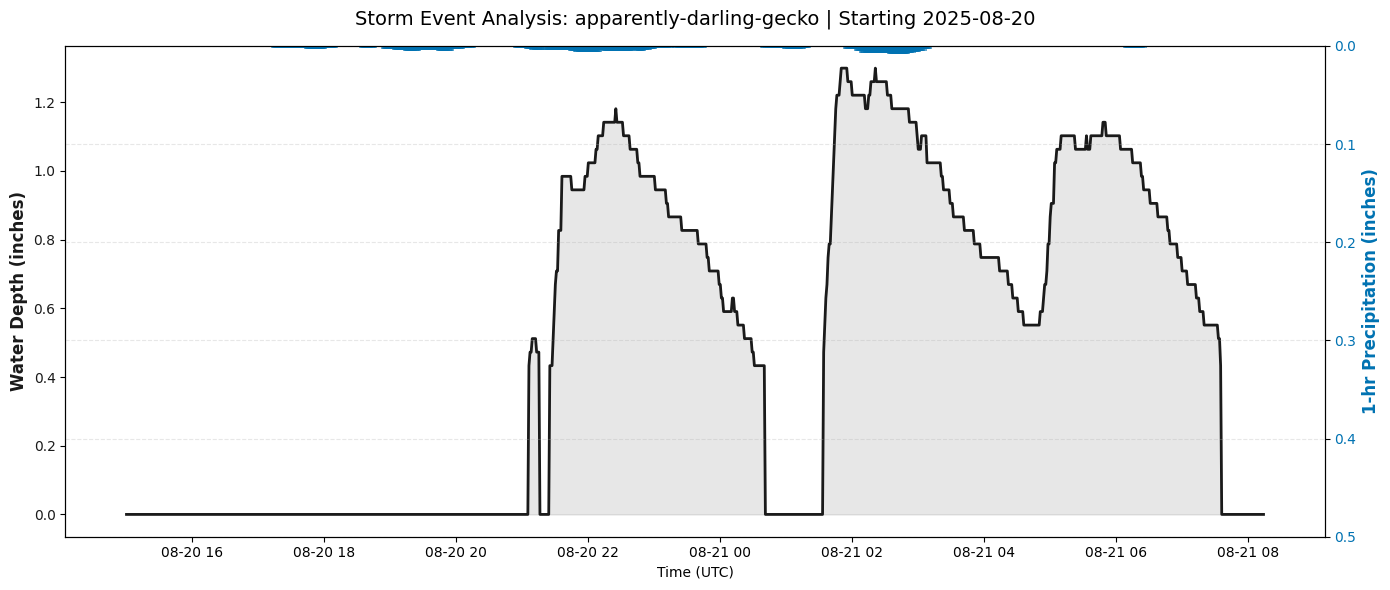

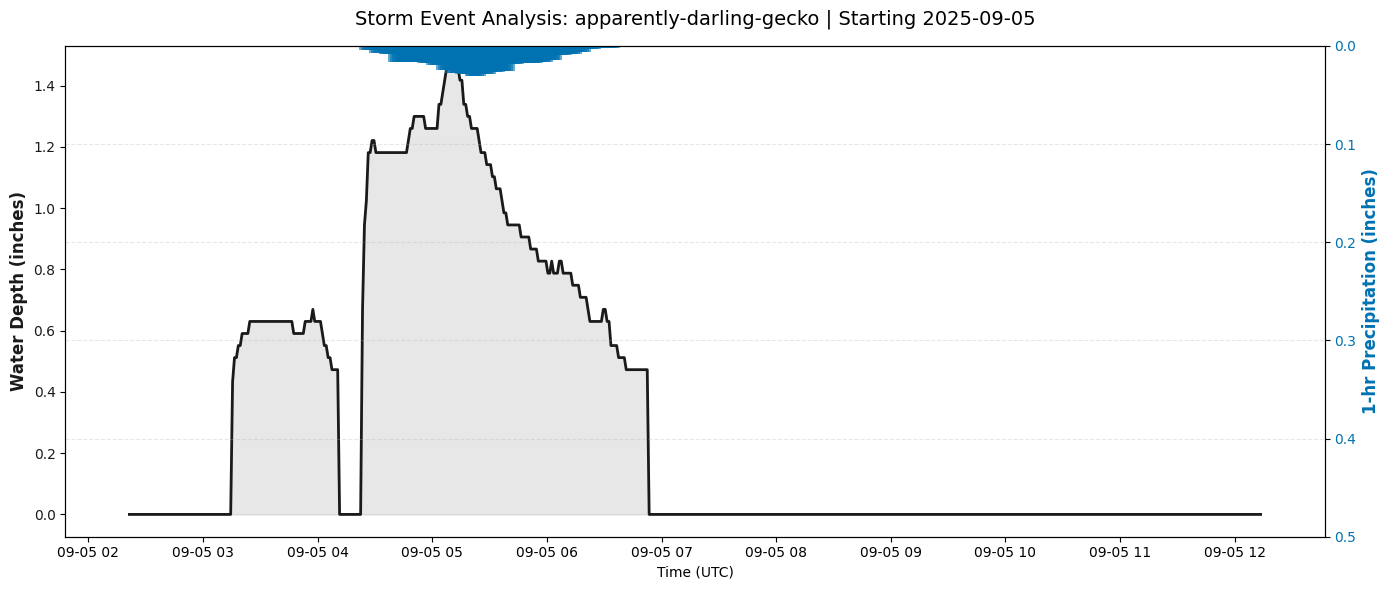

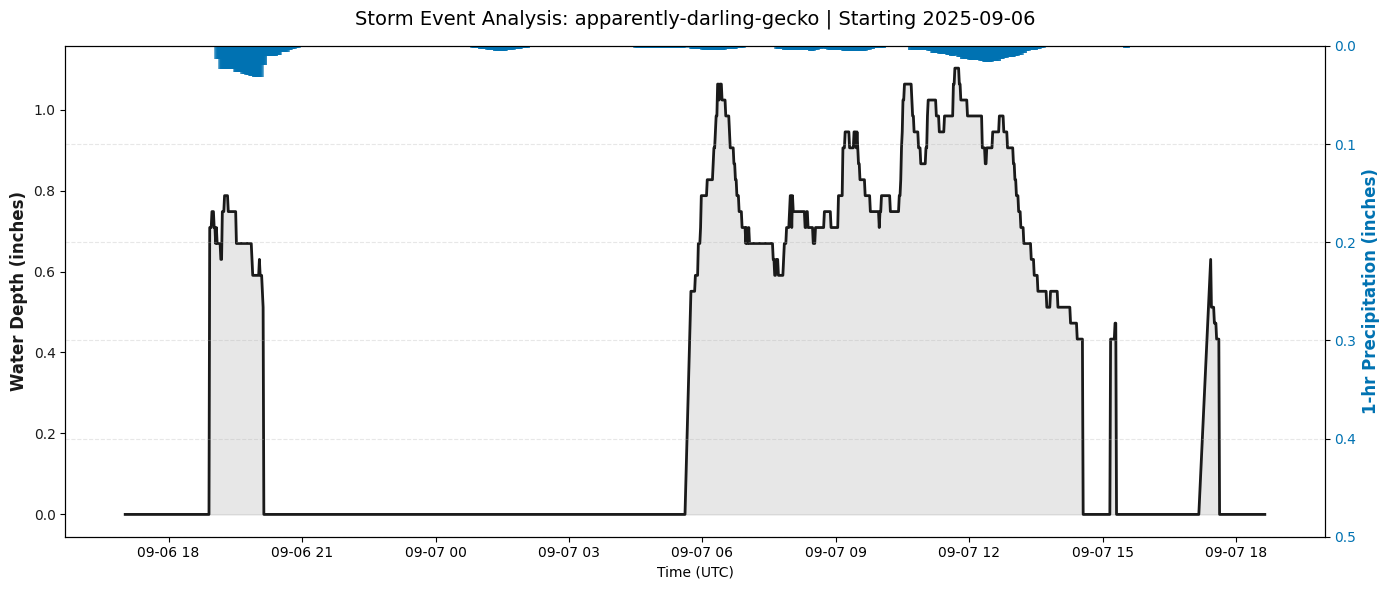

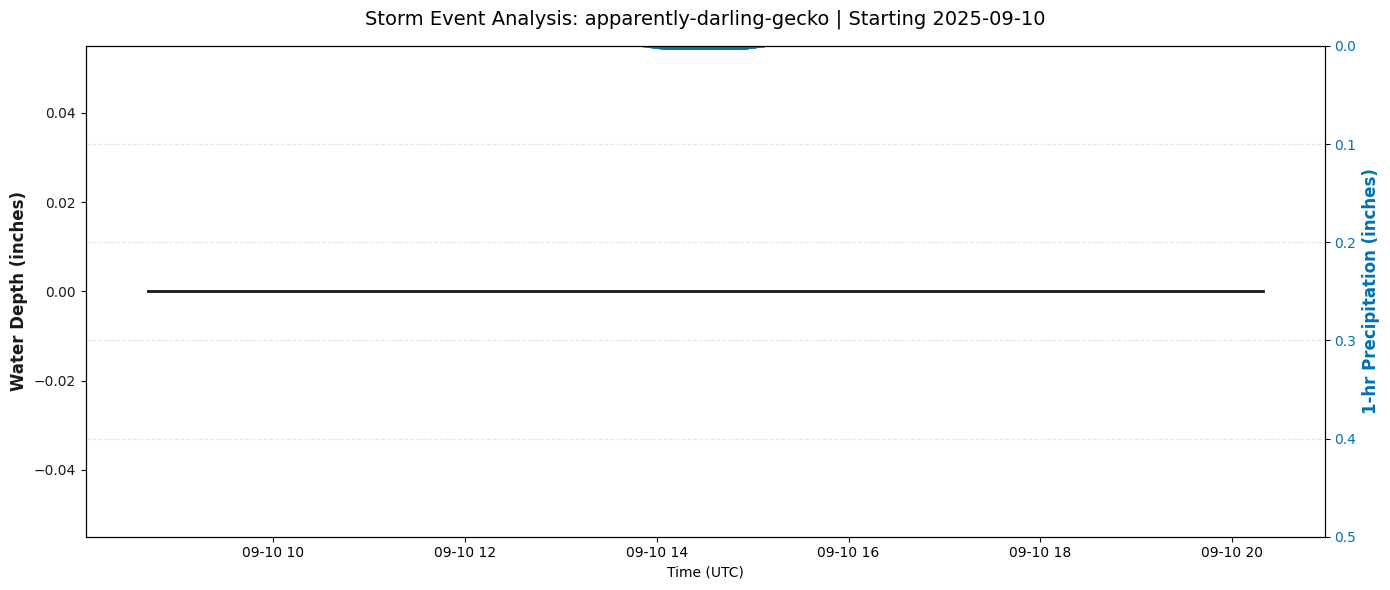

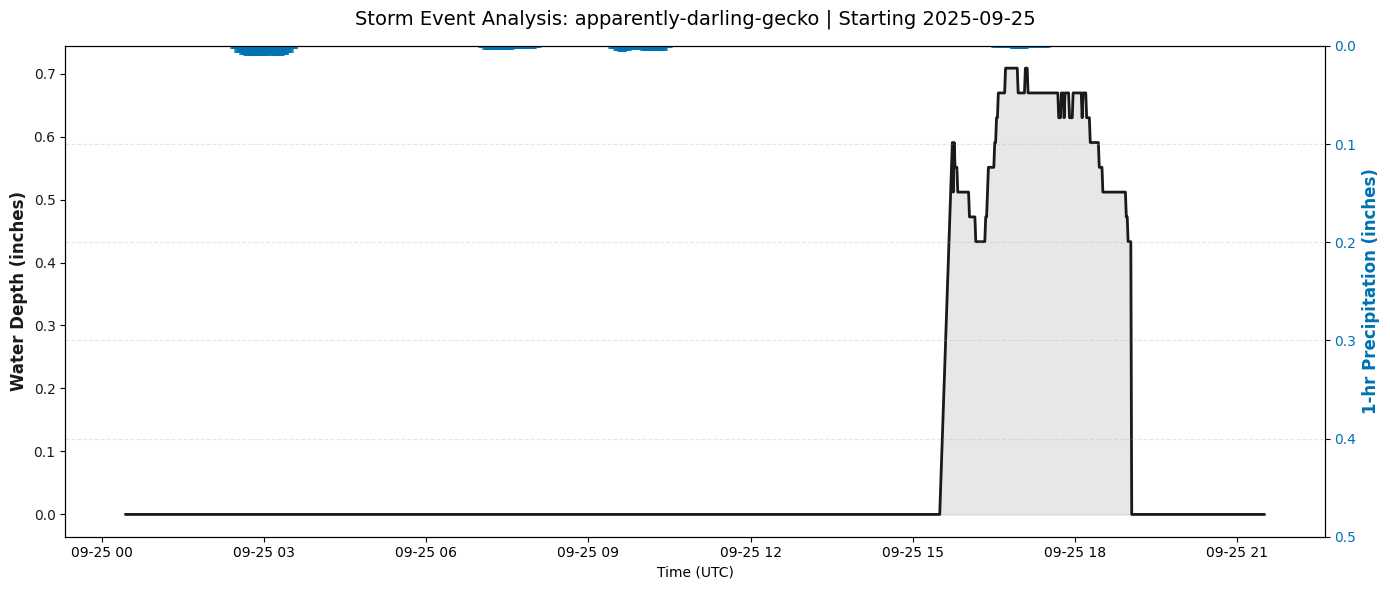

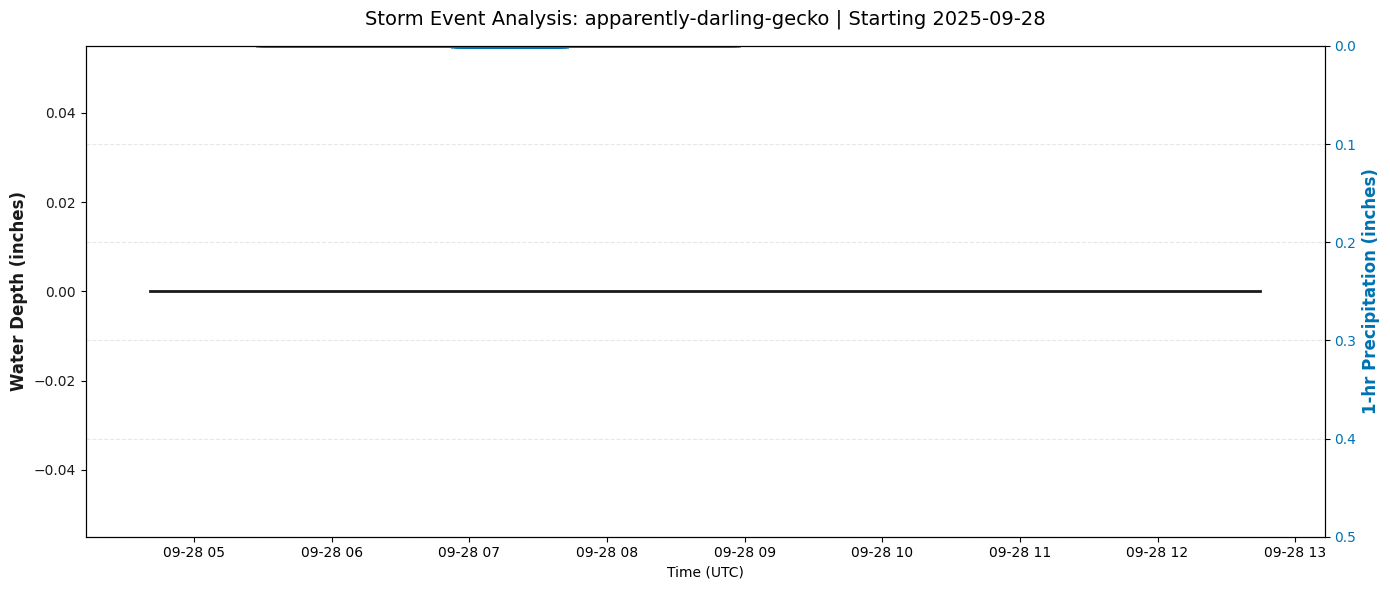

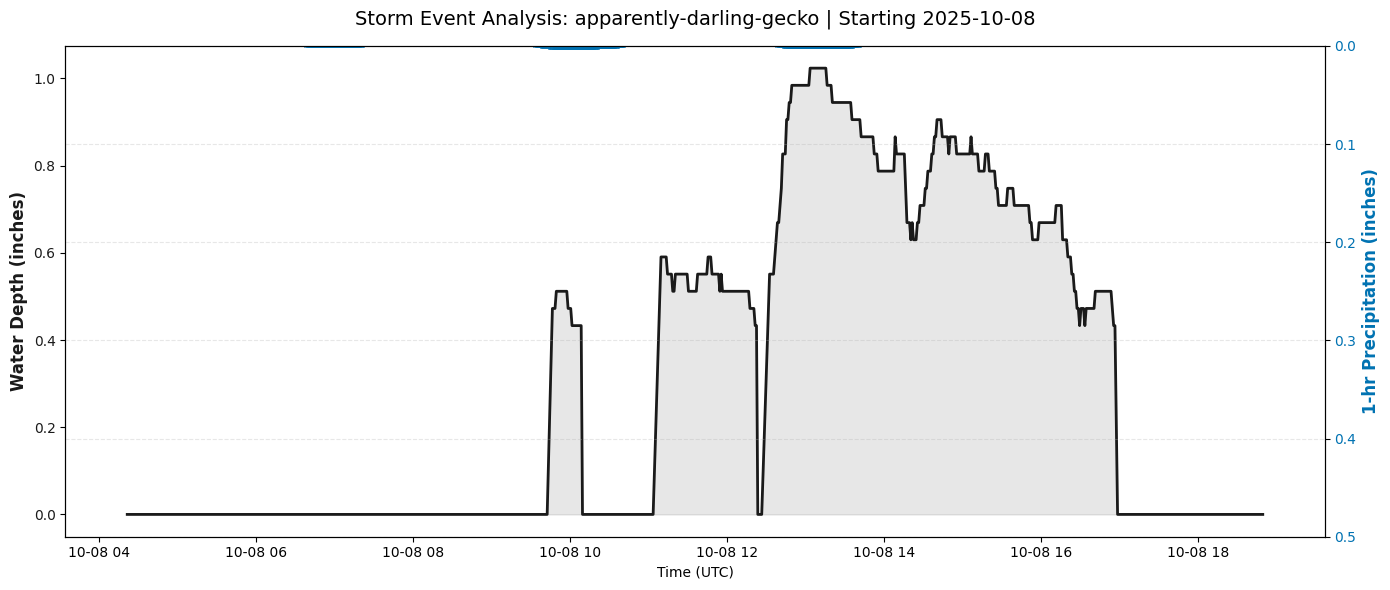

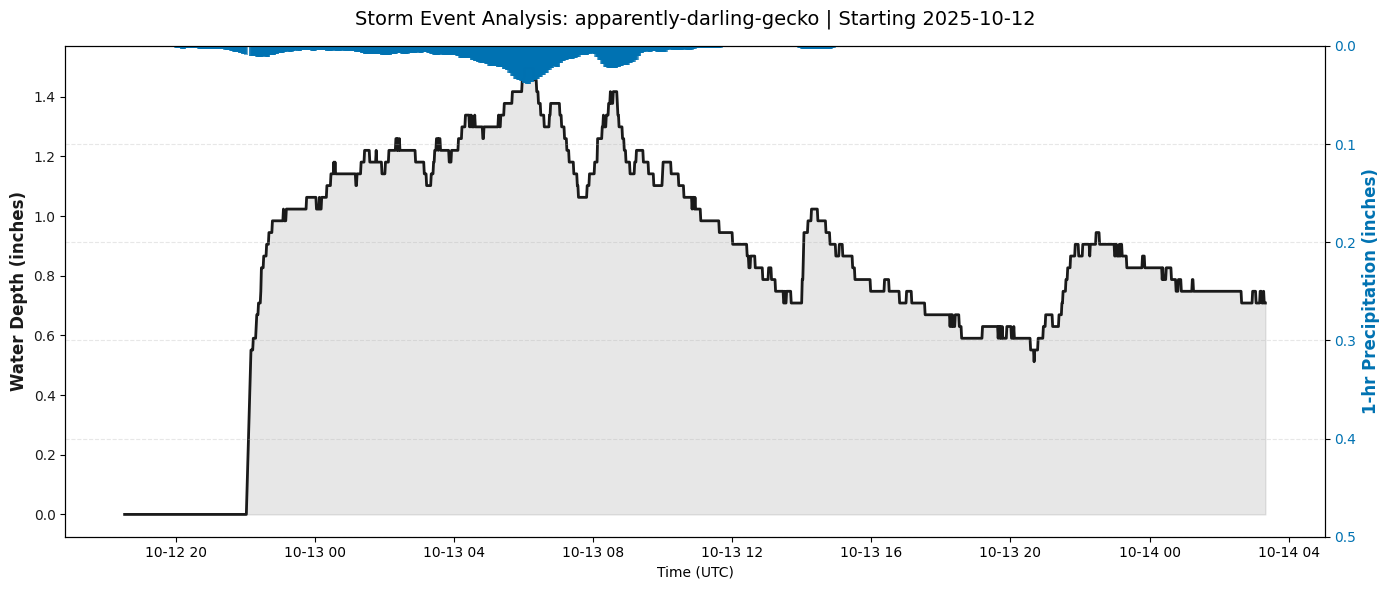

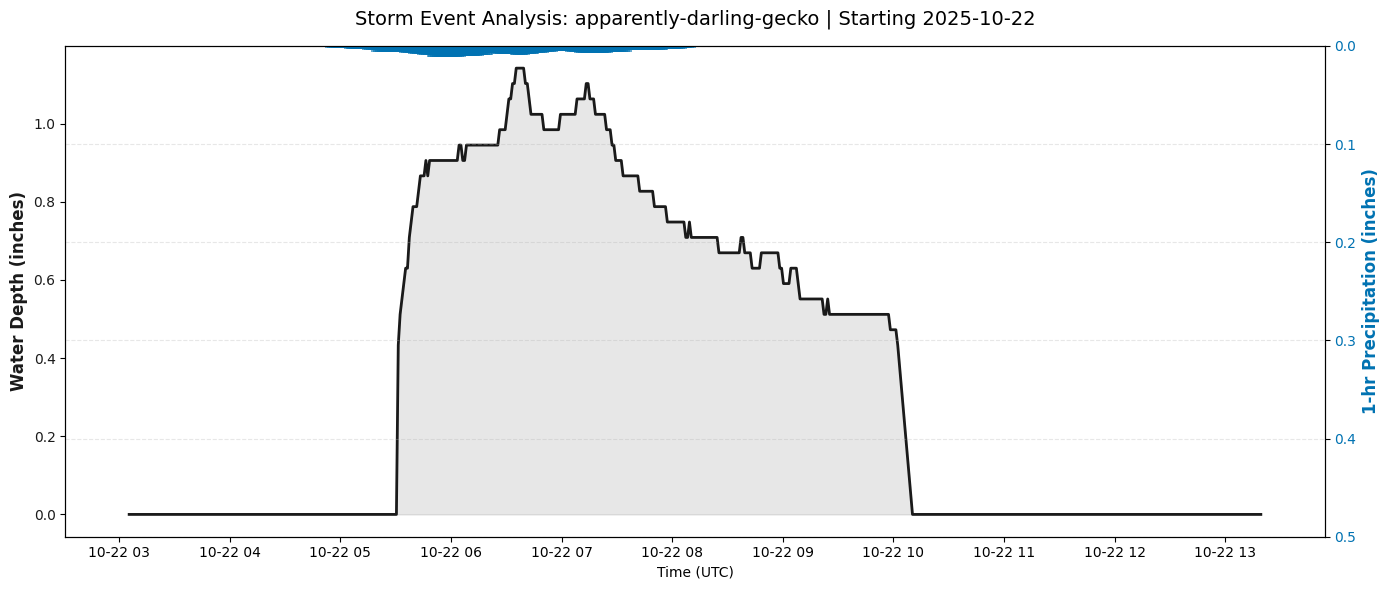

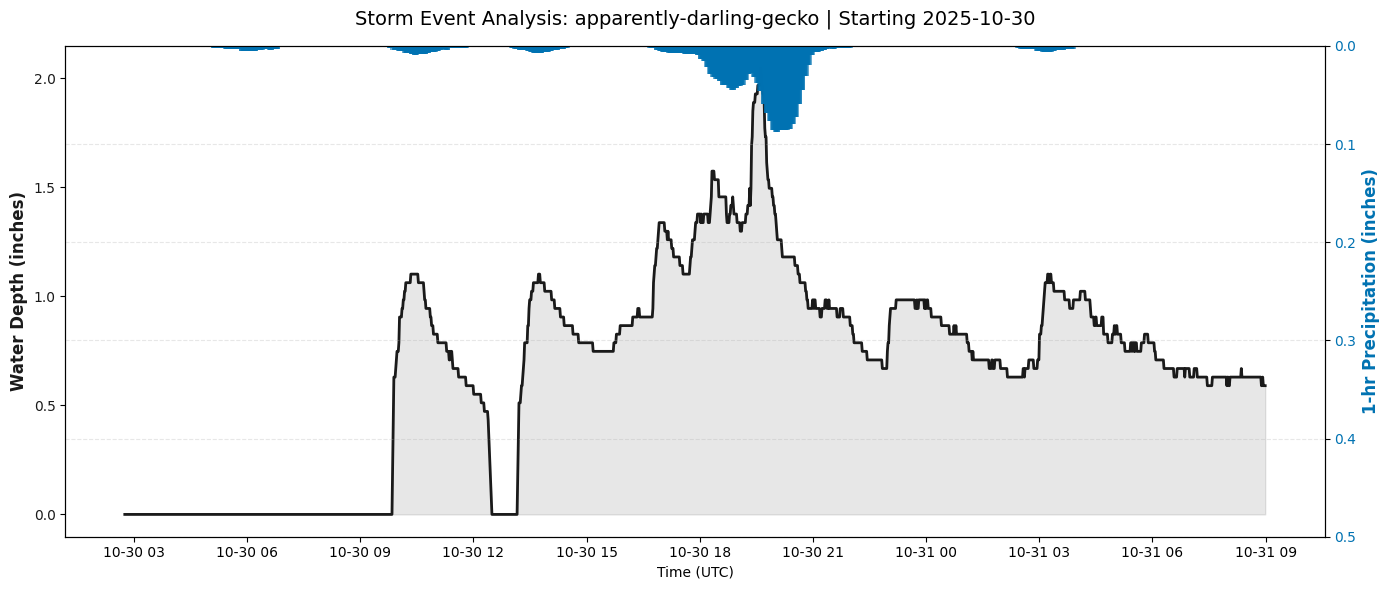

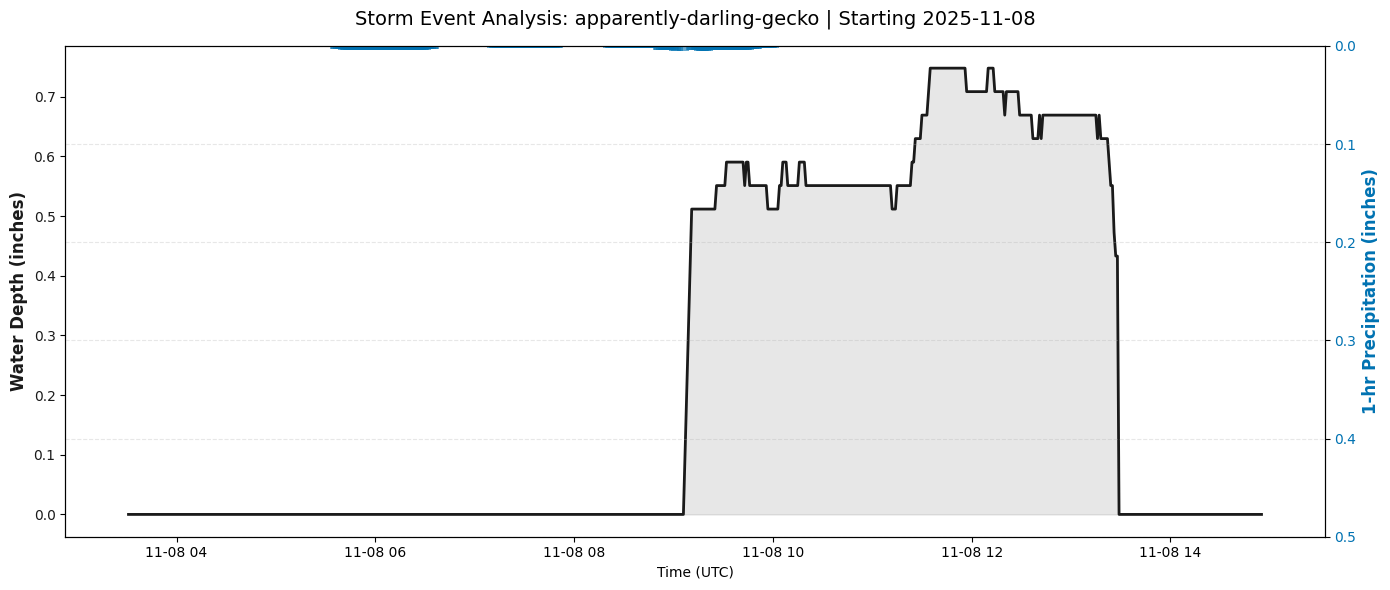

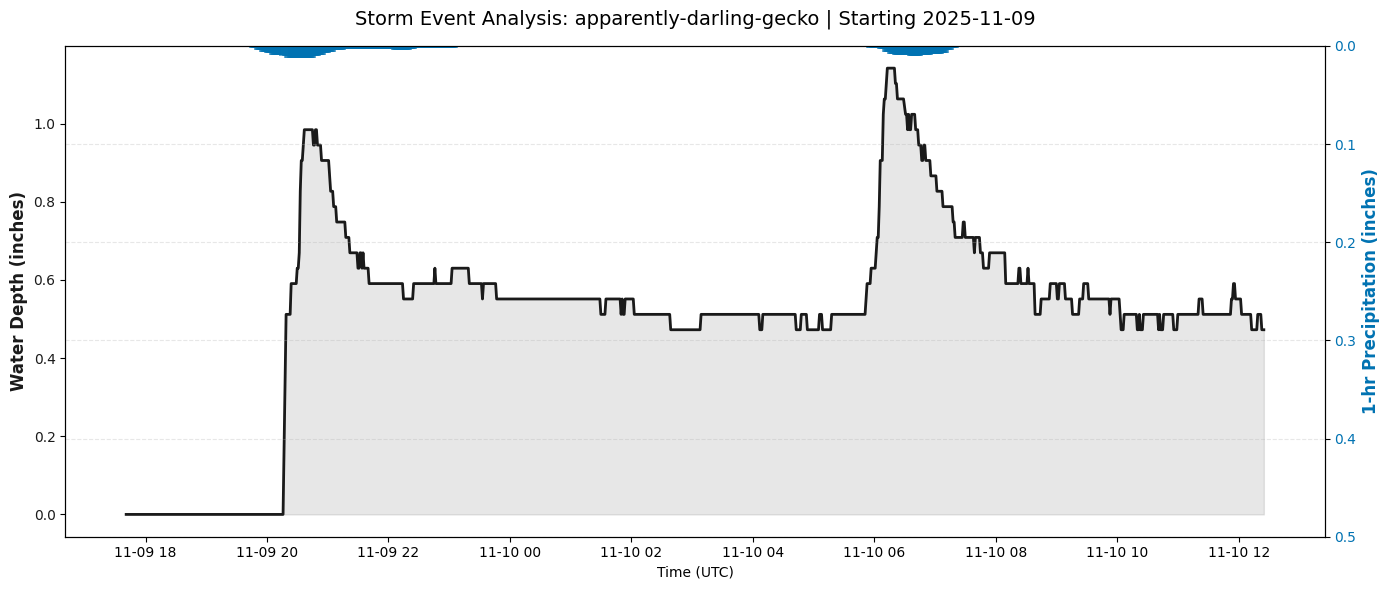

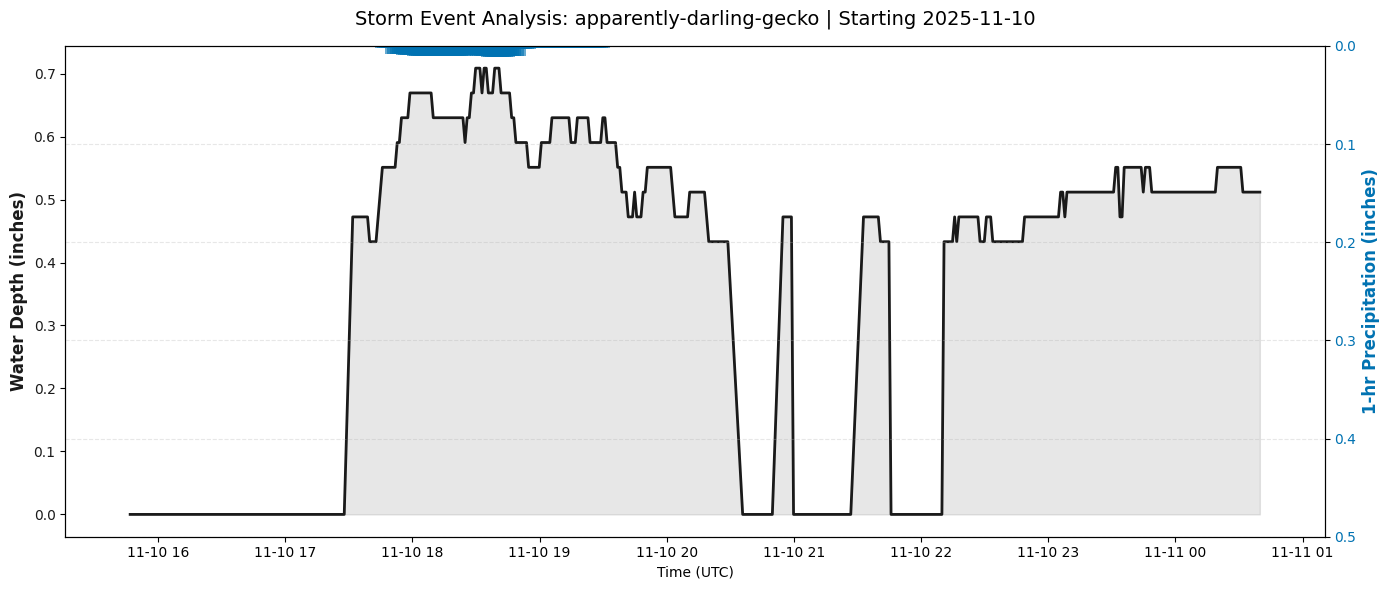

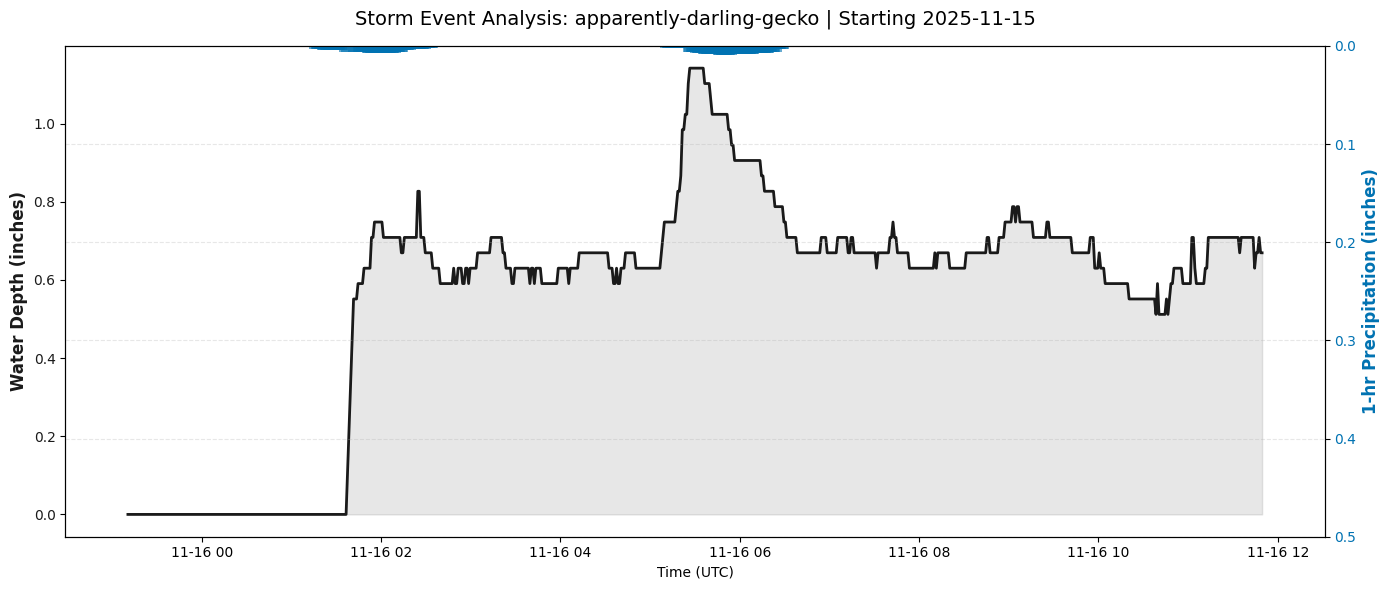

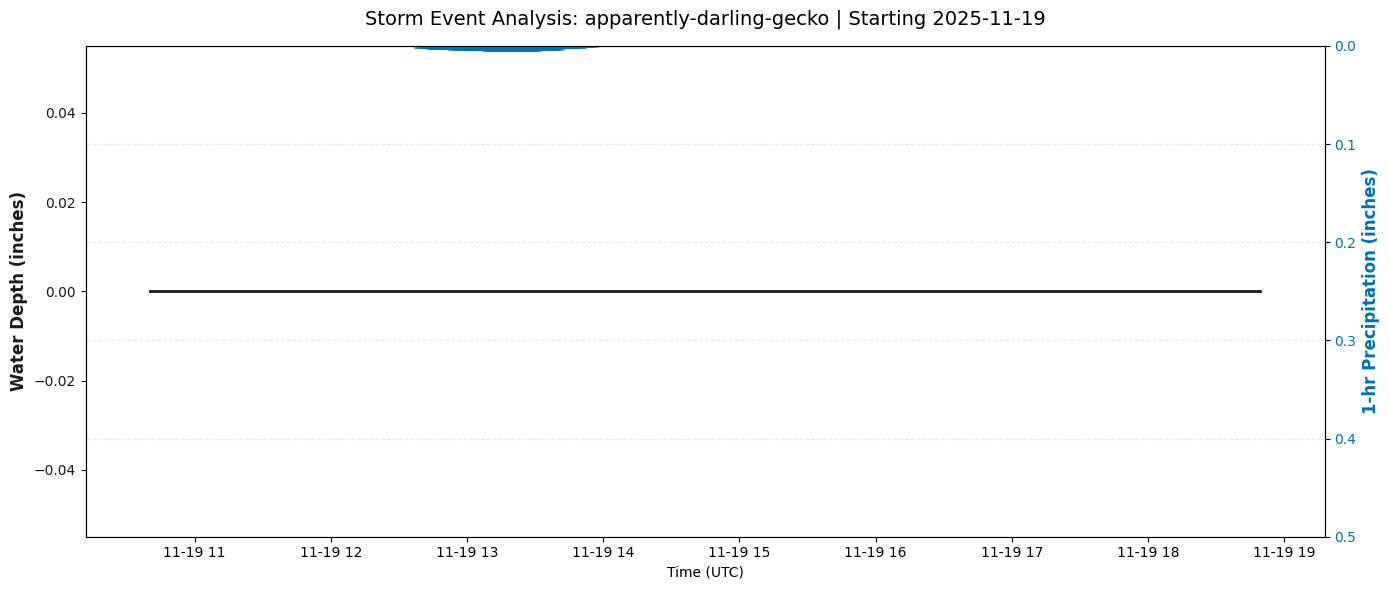

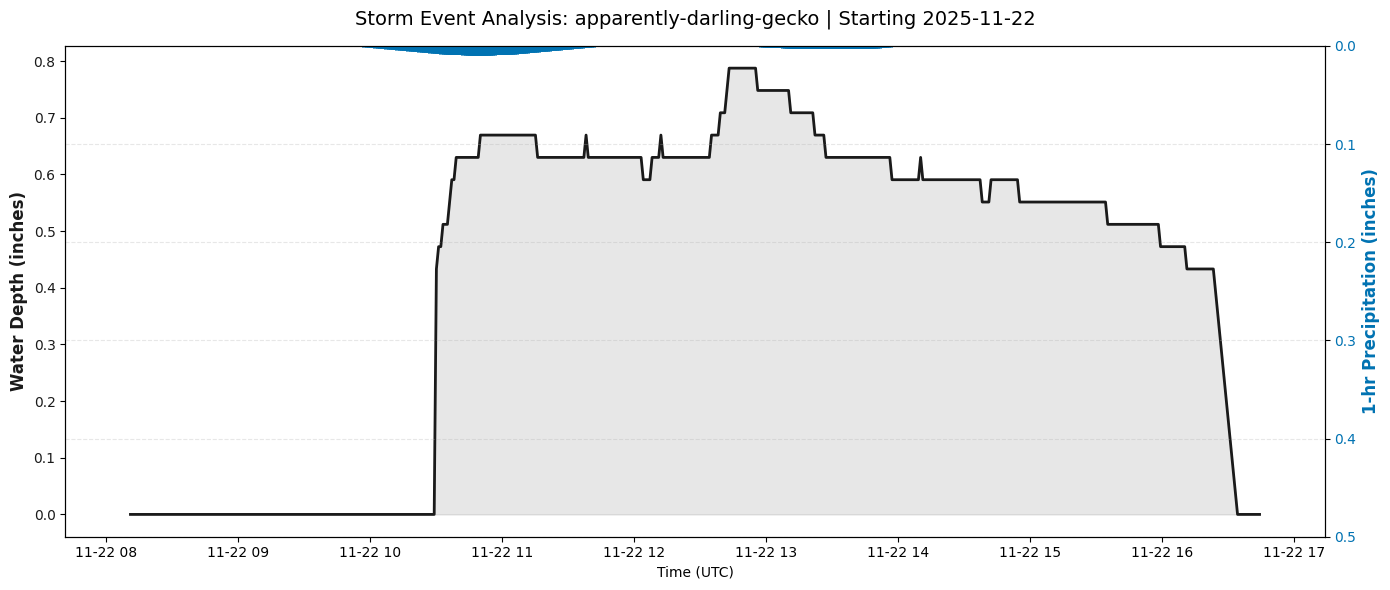

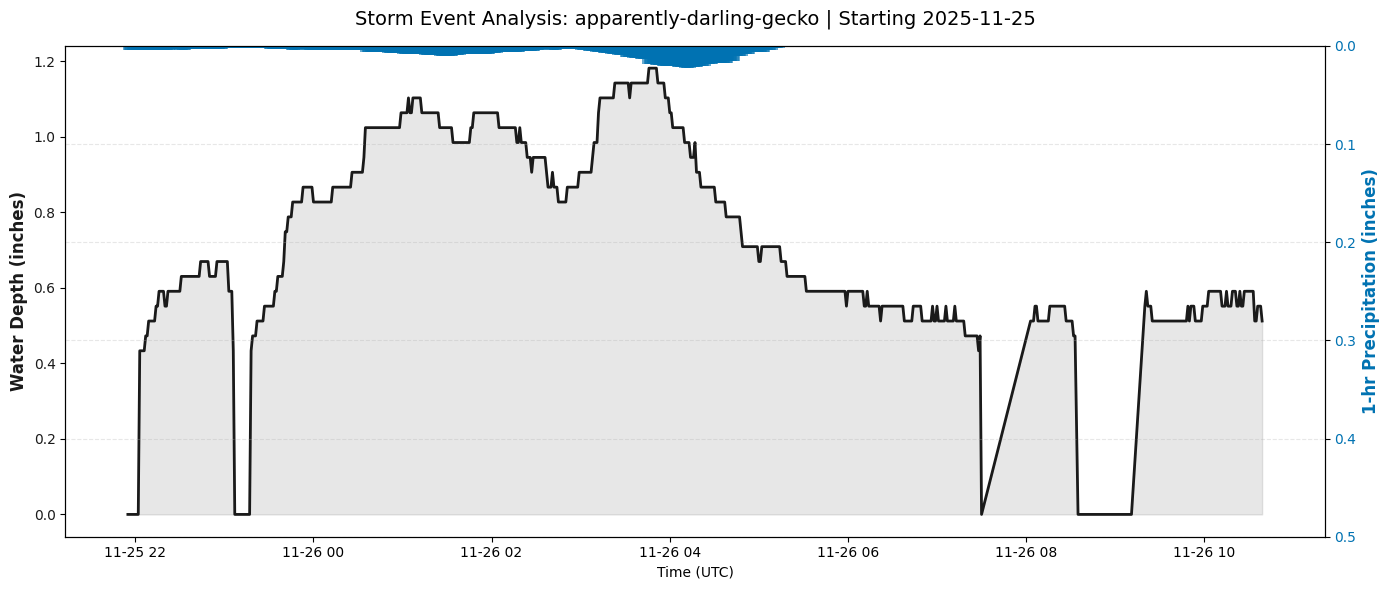

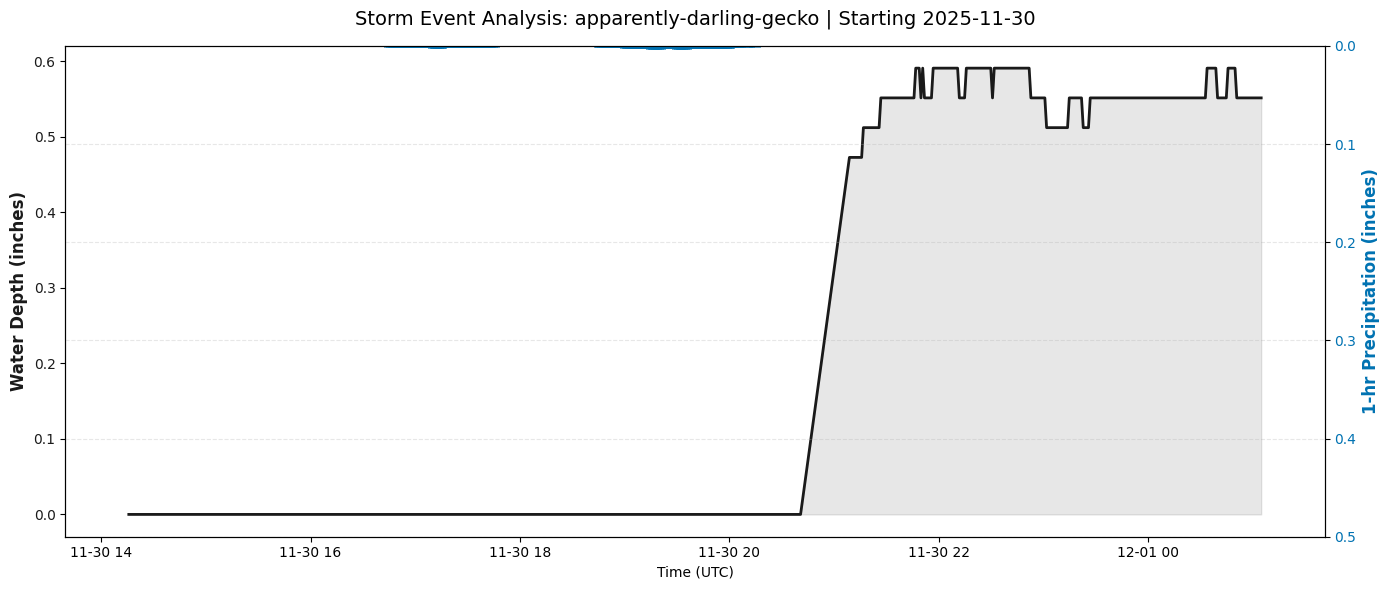

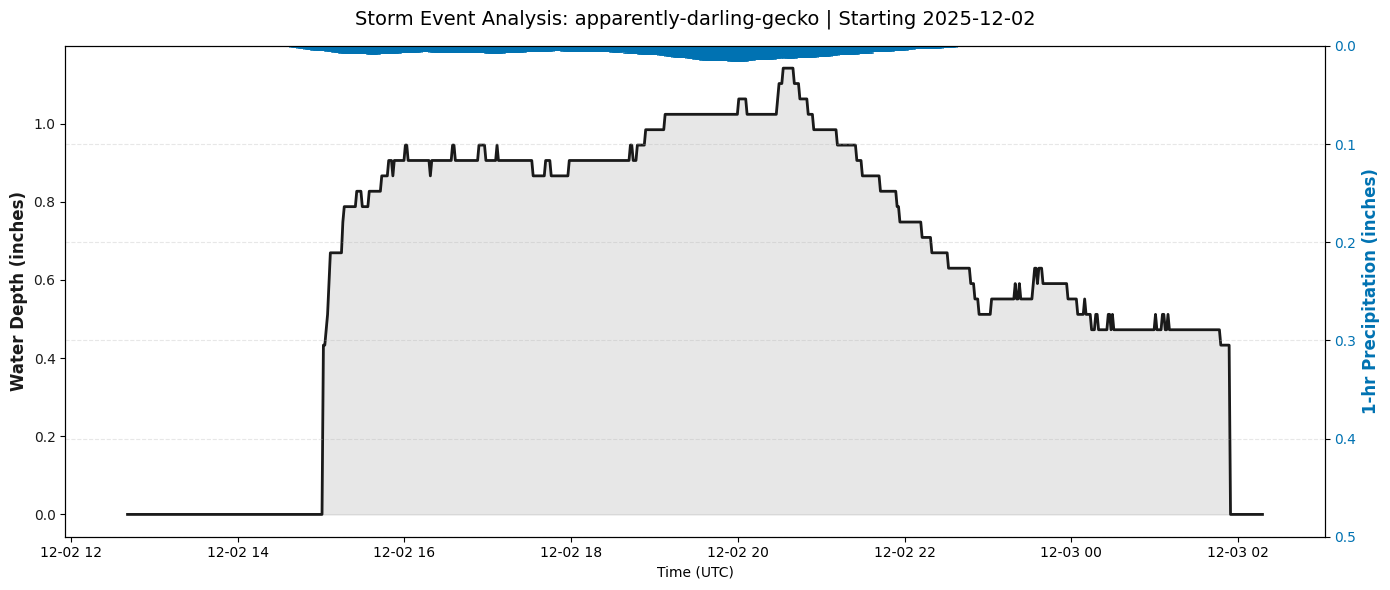

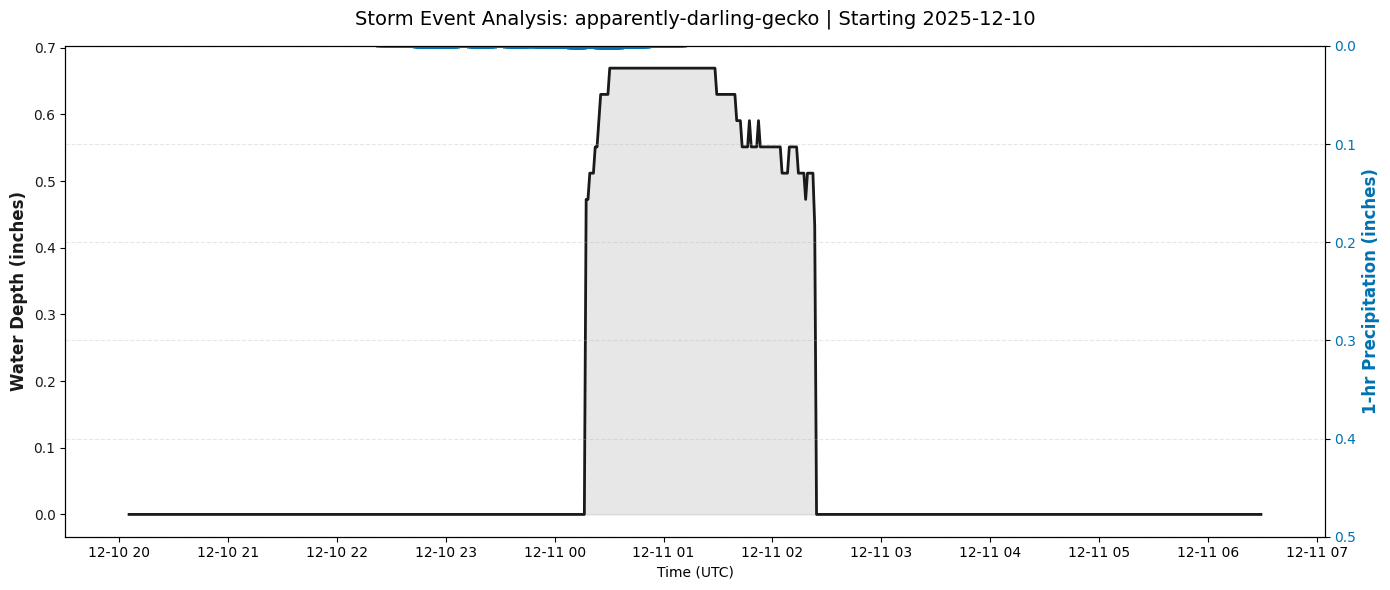

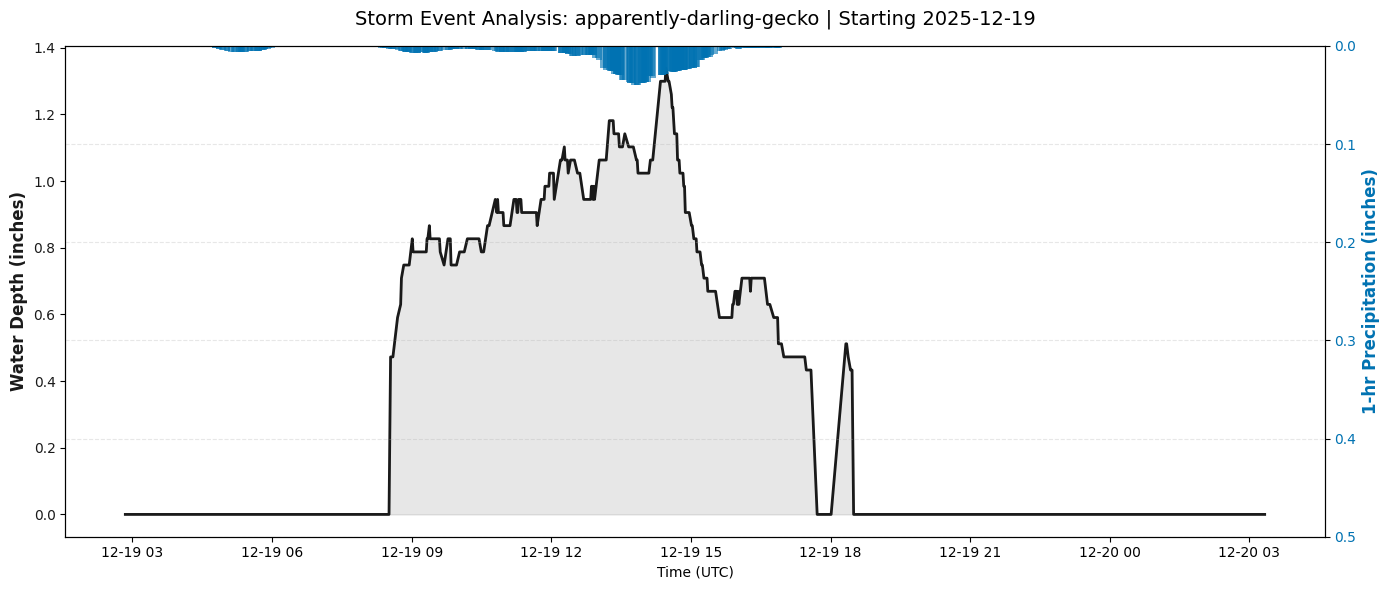

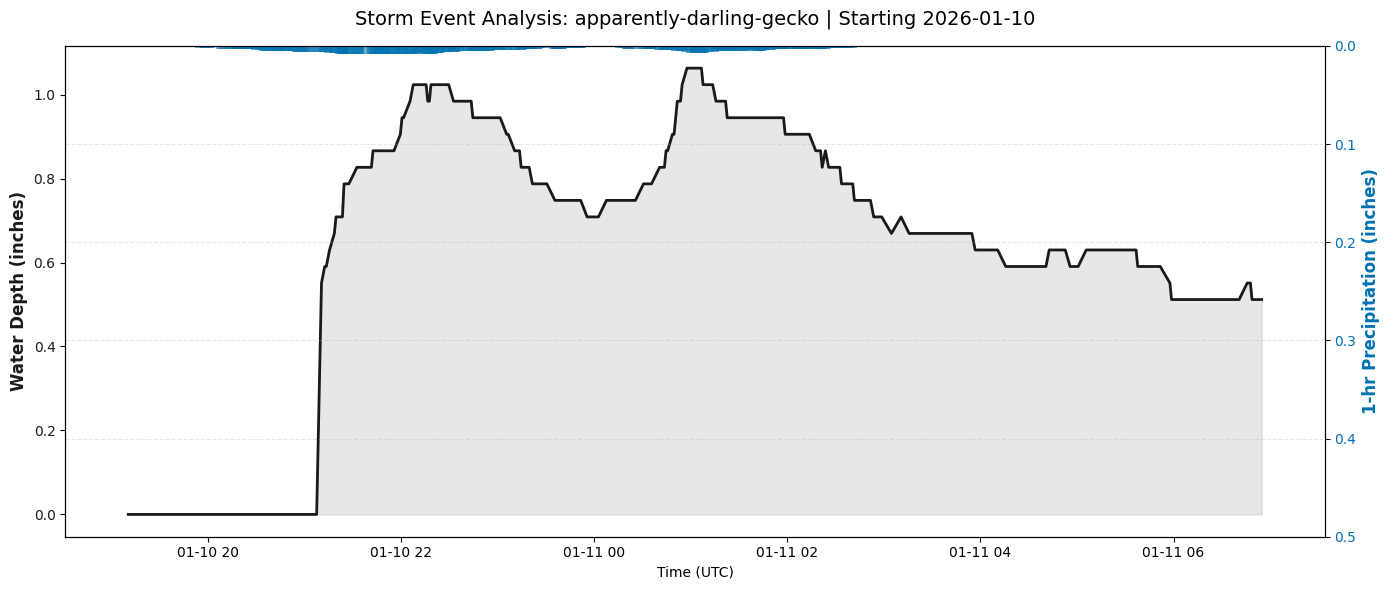

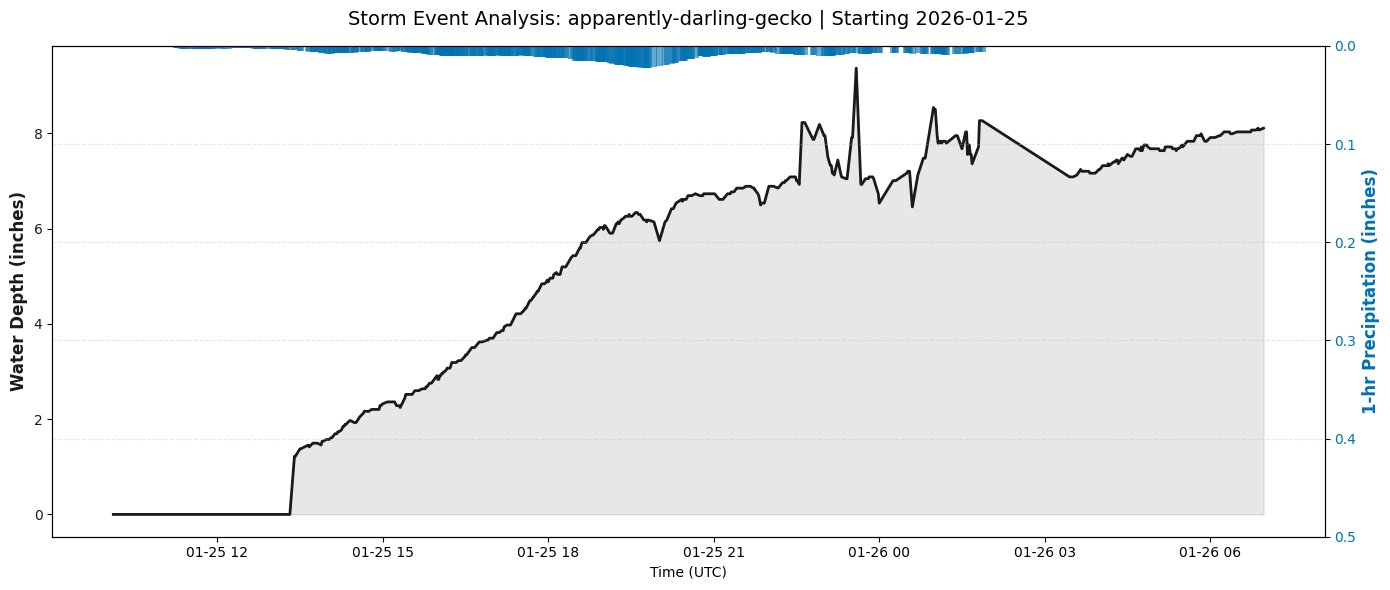

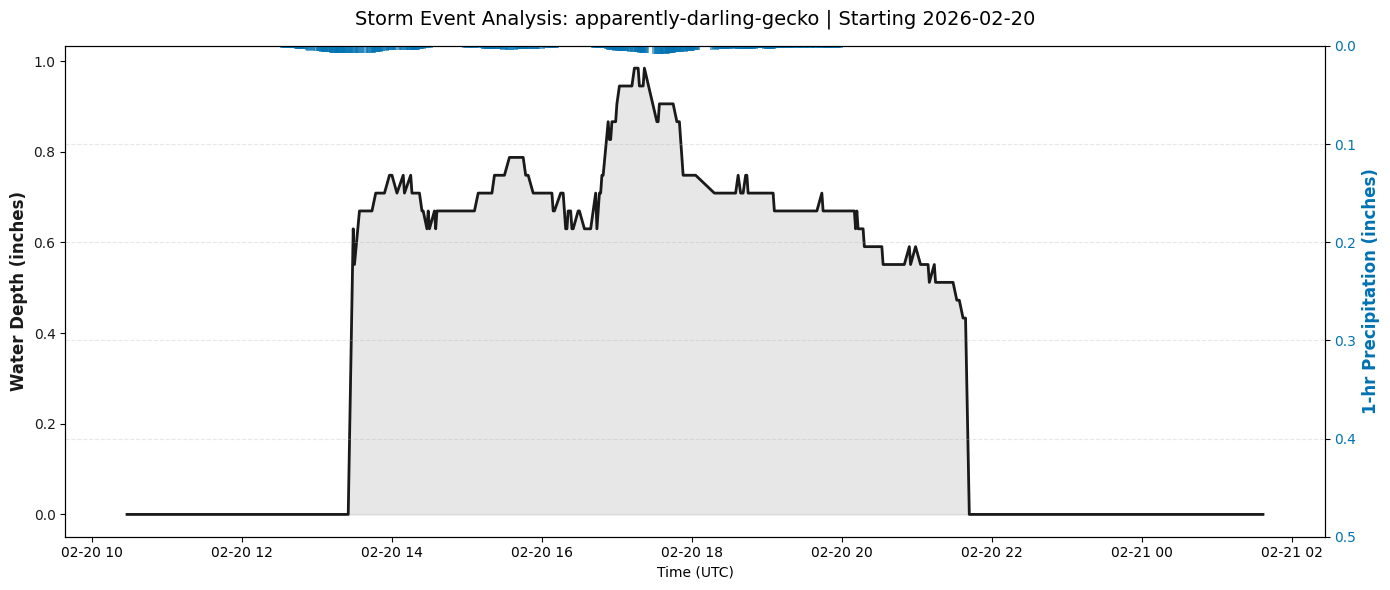

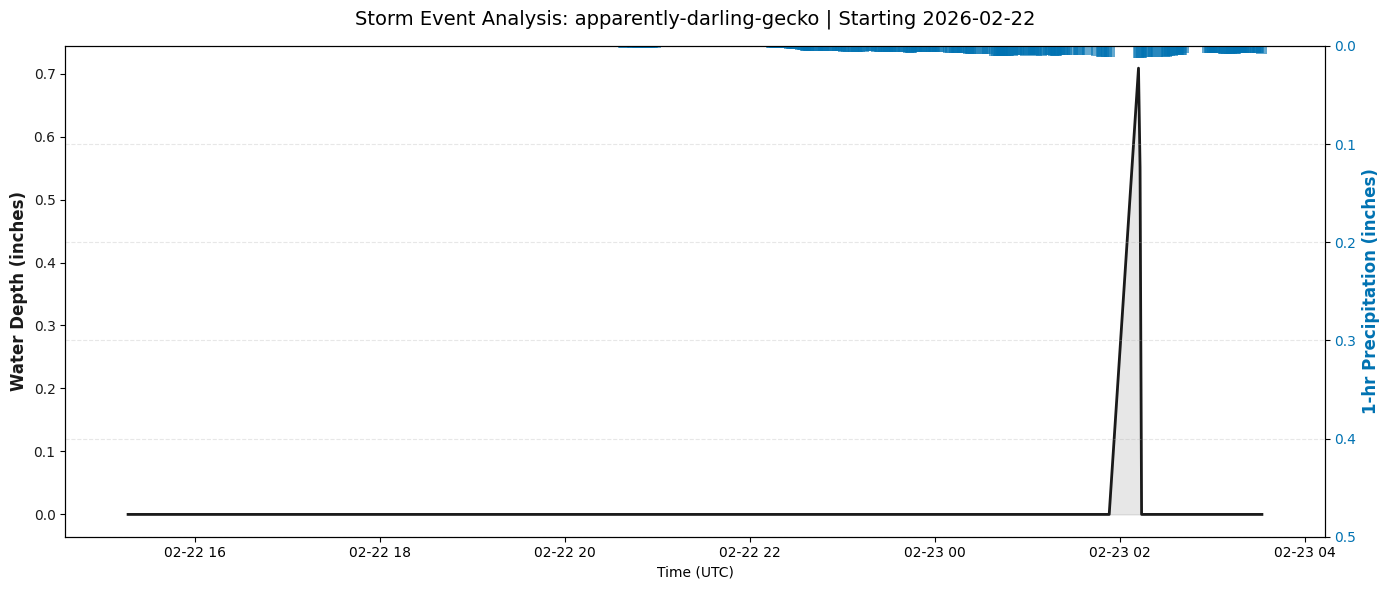

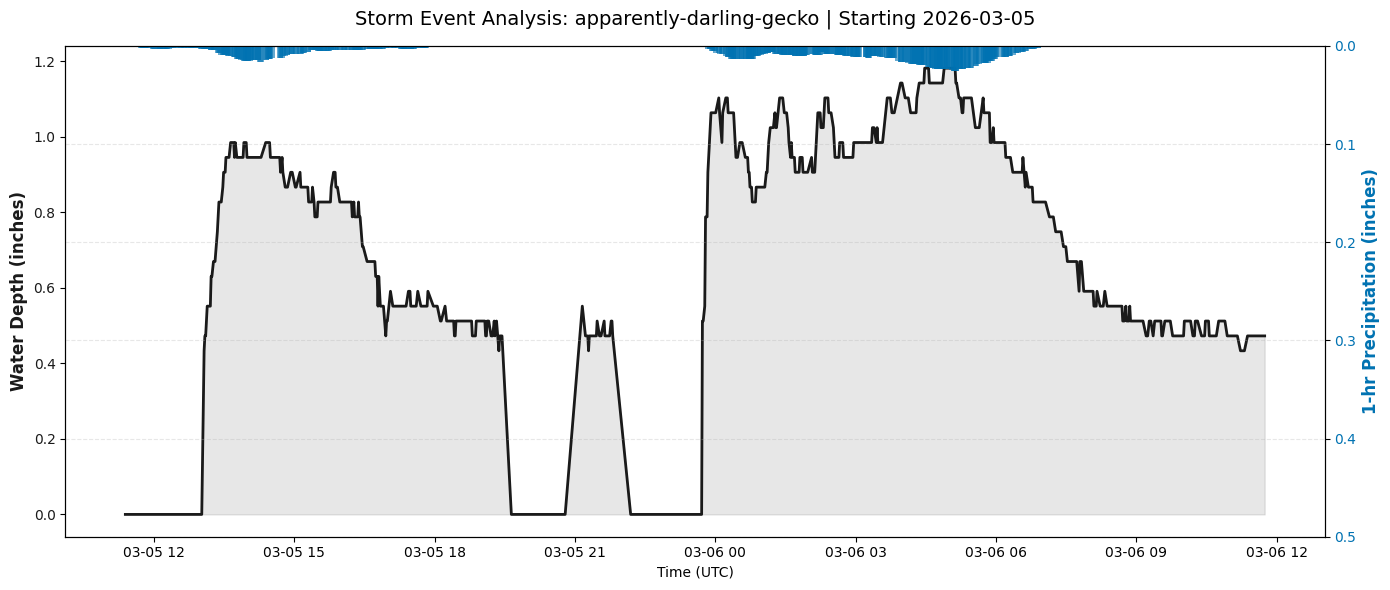

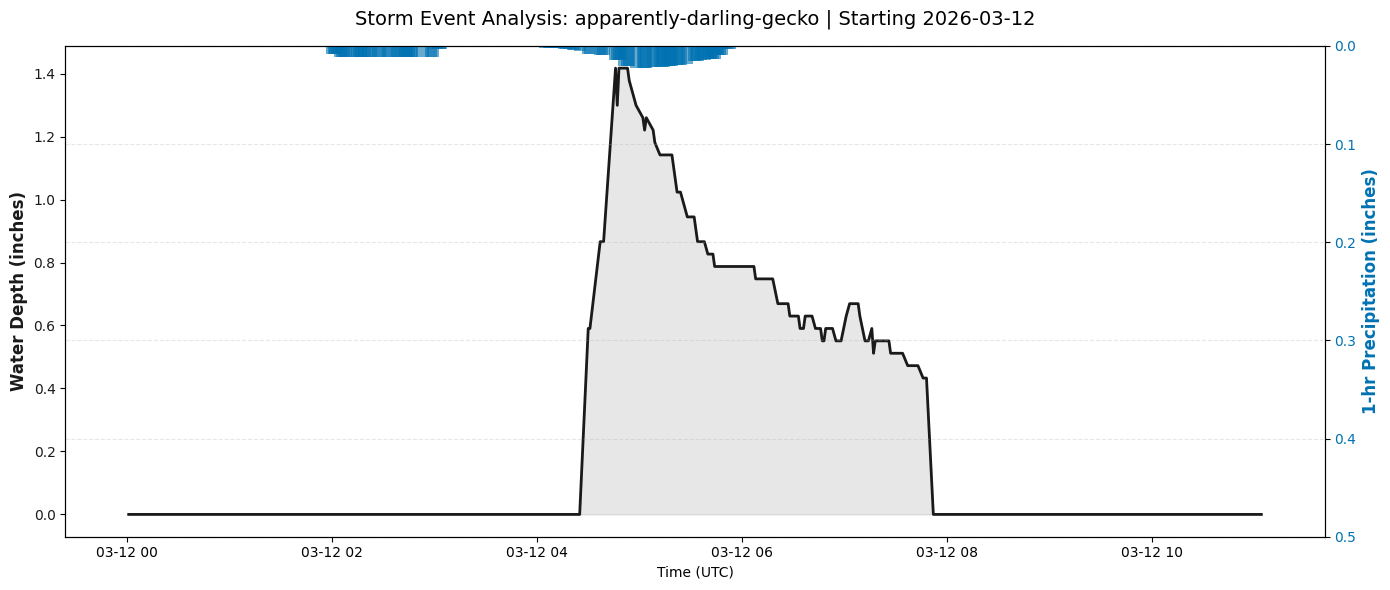

In [11]:
def plot_individual_storms(df, sensor_id):
    # 1. Filter and sort sensor data
    sensor_data = df[df['deployment_id'] == sensor_id].sort_values('time').copy()
    
    if sensor_data.empty:
        print(f"❌ No data found for ID: {sensor_id}")
        return

    # 2. EVENT ID LOGIC: Group rows where time gap <= 120 minutes
    # This prevents the "400k events" error by keeping buffers together
    sensor_data['time_diff'] = sensor_data['time'].diff().dt.total_seconds() / 60
    sensor_data['event_id'] = (sensor_data['time_diff'] > 120).cumsum()
    
    unique_events = sensor_data['event_id'].unique()
    print(f"🔍 Found {len(unique_events)} discrete storm windows for {sensor_id}.")

    # 3. Plotting Loop
    for eid in unique_events:
        subset = sensor_data[sensor_data['event_id'] == eid]
        
        # Filtering out 'noise' (events shorter than 6 hours)
        if len(subset) < 360:
            continue
            
        fig, ax1 = plt.subplots(figsize=(14, 6), dpi=100)

        # Primary Axis: Water Depth (Black)
        color_depth = '#1a1a1a'
        ax1.set_xlabel('Time (UTC)', fontsize=10)
        ax1.set_ylabel('Water Depth (inches)', color=color_depth, fontsize=12, fontweight='bold')
        ax1.plot(subset['time'], subset['depth_inches'], color=color_depth, linewidth=2, label='Depth')
        ax1.fill_between(subset['time'], subset['depth_inches'], color=color_depth, alpha=0.1)
        ax1.tick_params(axis='y', labelcolor=color_depth)

        # Secondary Axis: Precipitation (Blue - Inverted)
        ax2 = ax1.twinx()
        color_rain = '#0072B2'
        ax2.set_ylabel('1-hr Precipitation (inches)', color=color_rain, fontsize=12, fontweight='bold')
        ax2.bar(subset['time'], subset['precip_1hr [inch]'], color=color_rain, width=0.005, alpha=0.6, label='Precip')
        
        # Scaling and Inversion
        max_rain = subset['precip_1hr [inch]'].max()
        ax2.set_ylim(max(max_rain * 4, 0.5), 0) 
        ax2.tick_params(axis='y', labelcolor=color_rain)

        # Title and Formatting
        event_start = subset['time'].min().strftime('%Y-%m-%d')
        plt.title(f"Storm Event Analysis: {sensor_id} | Starting {event_start}", fontsize=14, pad=15)
        plt.grid(True, linestyle='--', alpha=0.3)
        
        fig.tight_layout()
        plt.show()

# --- INTERACTIVE EXECUTION ---
plot_individual_storms(df_storms, "apparently-darling-gecko")

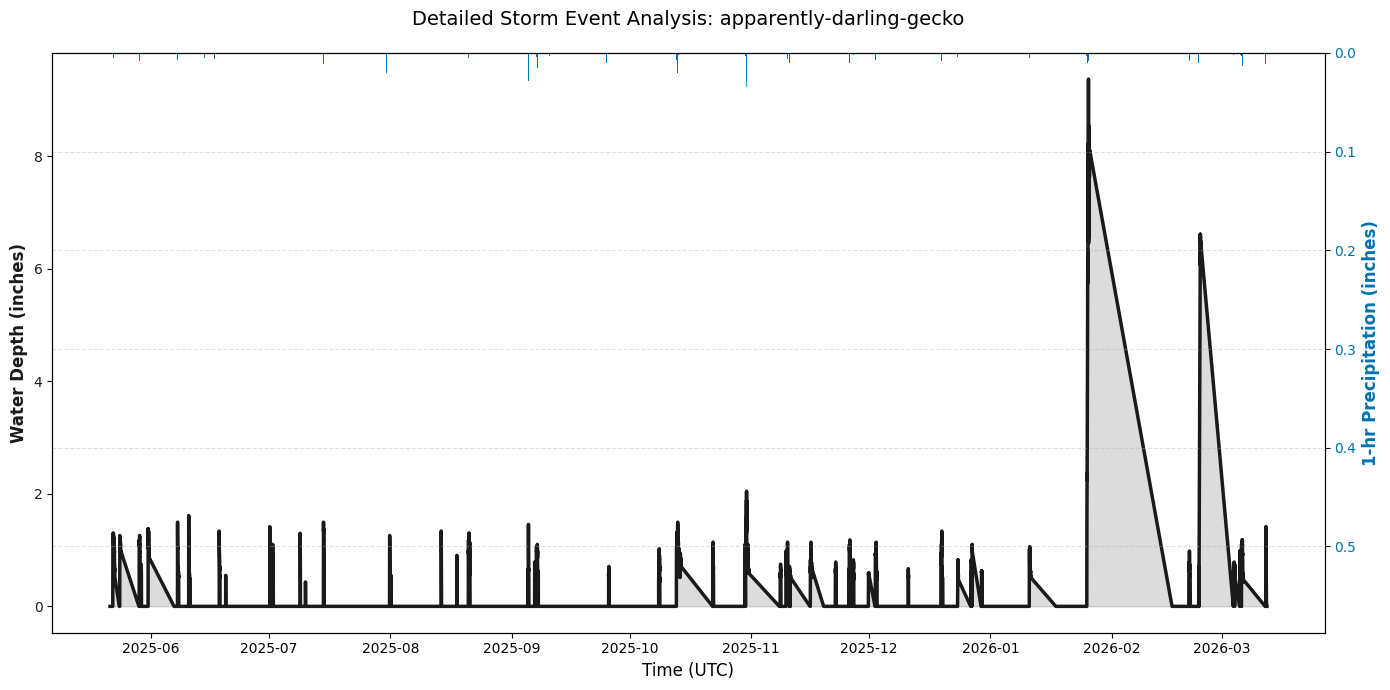

In [12]:
def plot_journal_hydrograph(df, sensor_id):
    # Subset data for a single sensor's event
    subset = df[df['deployment_id'] == sensor_id].sort_values('time')
    
    fig, ax1 = plt.subplots(figsize=(14, 7), dpi=100)

    # --- Axis 1: Flood Depth ---
    color_depth = '#1a1a1a' # Dark grey/black for clarity
    ax1.set_xlabel('Time (UTC)', fontsize=12)
    ax1.set_ylabel('Water Depth (inches)', color=color_depth, fontsize=12, fontweight='bold')
    ax1.plot(subset['time'], subset['depth_inches'], color=color_depth, linewidth=2.5, label='Observed Depth')
    ax1.fill_between(subset['time'], subset['depth_inches'], color=color_depth, alpha=0.15)
    ax1.tick_params(axis='y', labelcolor=color_depth)

    # --- Axis 2: Precipitation (Inverted) ---
    ax2 = ax1.twinx()
    color_rain = '#0072B2' # Hydrology Blue
    ax2.set_ylabel('1-hr Precipitation (inches)', color=color_rain, fontsize=12, fontweight='bold')
    ax2.bar(subset['time'], subset['precip_1hr [inch]'], color=color_rain, width=0.005, alpha=0.7, label='Precipitation')
    
    # Invert Axis 2: High rain comes from the top
    ax2.set_ylim(subset['precip_1hr [inch]'].max() * 4, 0) 
    ax2.tick_params(axis='y', labelcolor=color_rain)

    # Annotate the Buffers 
    plt.title(f"Detailed Storm Event Analysis: {sensor_id}", fontsize=14, pad=20)
    plt.grid(True, which='both', linestyle='--', alpha=0.4)
    
    fig.tight_layout()
    plt.show()

plot_journal_hydrograph(df_storms, df_storms["deployment_id"].iloc[0])

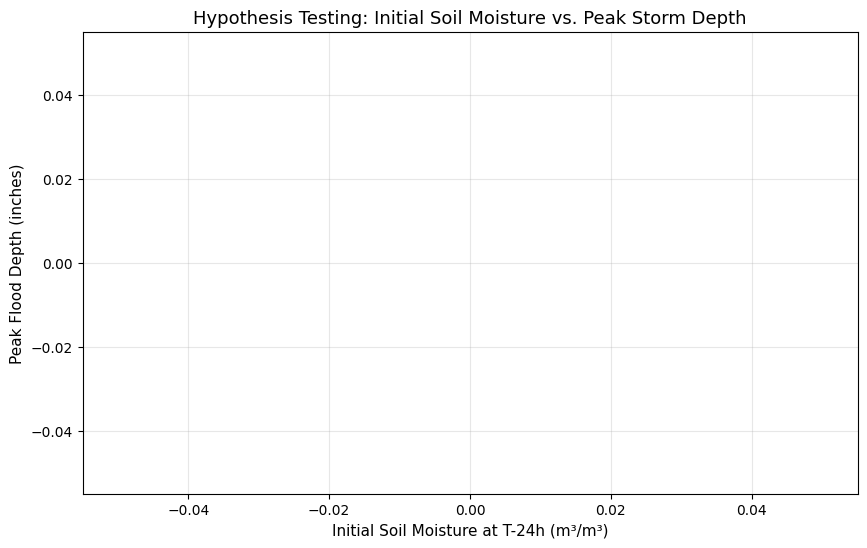

In [13]:
def plot_antecedent_correlation(df):
    # Group by sensor/event to find starting moisture vs peak depth
    # We define 'starting moisture' as the first record in the 24h window
    event_stats = df.groupby('deployment_id').agg({
        'soil_moisture_05cm [m^3/m^3]': 'first',
        'depth_inches': 'max'
    }).rename(columns={'depth_inches': 'peak_depth', 'soil_moisture_05cm [m^3/m^3]': 'initial_moisture'})

    plt.figure(figsize=(10, 6))
    sns.regplot(x='initial_moisture', y='peak_depth', data=event_stats, 
                scatter_kws={'alpha':0.6, 'color':'#2c3e50'}, 
                line_kws={'color':'#e74c3c', 'lw':2})
    
    plt.title("Hypothesis Testing: Initial Soil Moisture vs. Peak Storm Depth", fontsize=13)
    plt.xlabel("Initial Soil Moisture at T-24h (m³/m³)", fontsize=11)
    plt.ylabel("Peak Flood Depth (inches)", fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.show()

plot_antecedent_correlation(df_storms)

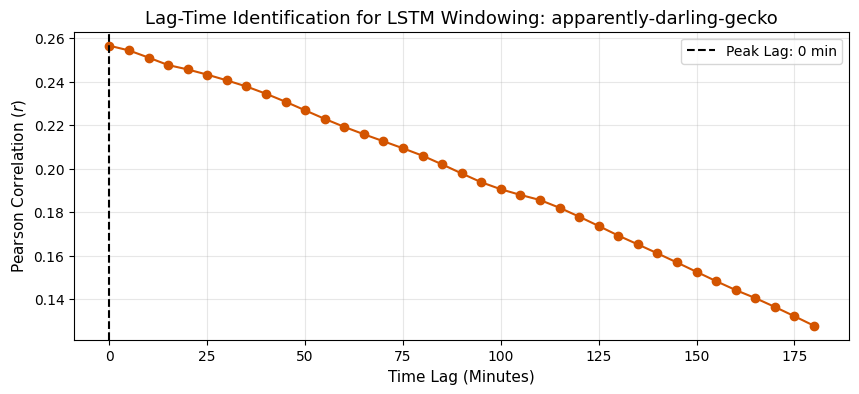

In [14]:
def plot_lag_correlation(df, sensor_id):
    sensor_data = df[df['deployment_id'] == sensor_id].copy()
    
    # Calculate correlations at different lags (in 5-min increments)
    lags = np.arange(0, 37) * 5 # 0 to 180 minutes
    corrs = []
    
    for l in lags:
        # Shift precip forward to see correlation with depth
        shifted_rain = sensor_data['precip_1hr [inch]'].shift(l // 1) # Simplified lag
        corrs.append(sensor_data['depth_inches'].corr(shifted_rain))
        
    plt.figure(figsize=(10, 4))
    plt.plot(lags, corrs, marker='o', linestyle='-', color='#d35400')
    plt.axvline(lags[np.argmax(corrs)], color='black', linestyle='--', label=f'Peak Lag: {lags[np.argmax(corrs)]} min')
    
    plt.title(f"Lag-Time Identification for LSTM Windowing: {sensor_id}", fontsize=13)
    plt.xlabel("Time Lag (Minutes)", fontsize=11)
    plt.ylabel("Pearson Correlation ($r$)", fontsize=11)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

plot_lag_correlation(df_storms, df_storms['deployment_id'].iloc[0])

In [15]:
features = [
    'temp_2m [degF]', 
    'relative_humidity [percent]', 
    'dewpoint [degF]',
    'elevation [feet]',
    'precip_1hr [inch]', 
    'precip_max_intensity [inch/hour]', 
    'precip_incremental [inch]',
    'total_precip_in', 
    'peak_intensity_inh', 
    'storm_duration_hr',
    'depth_inches' 
]

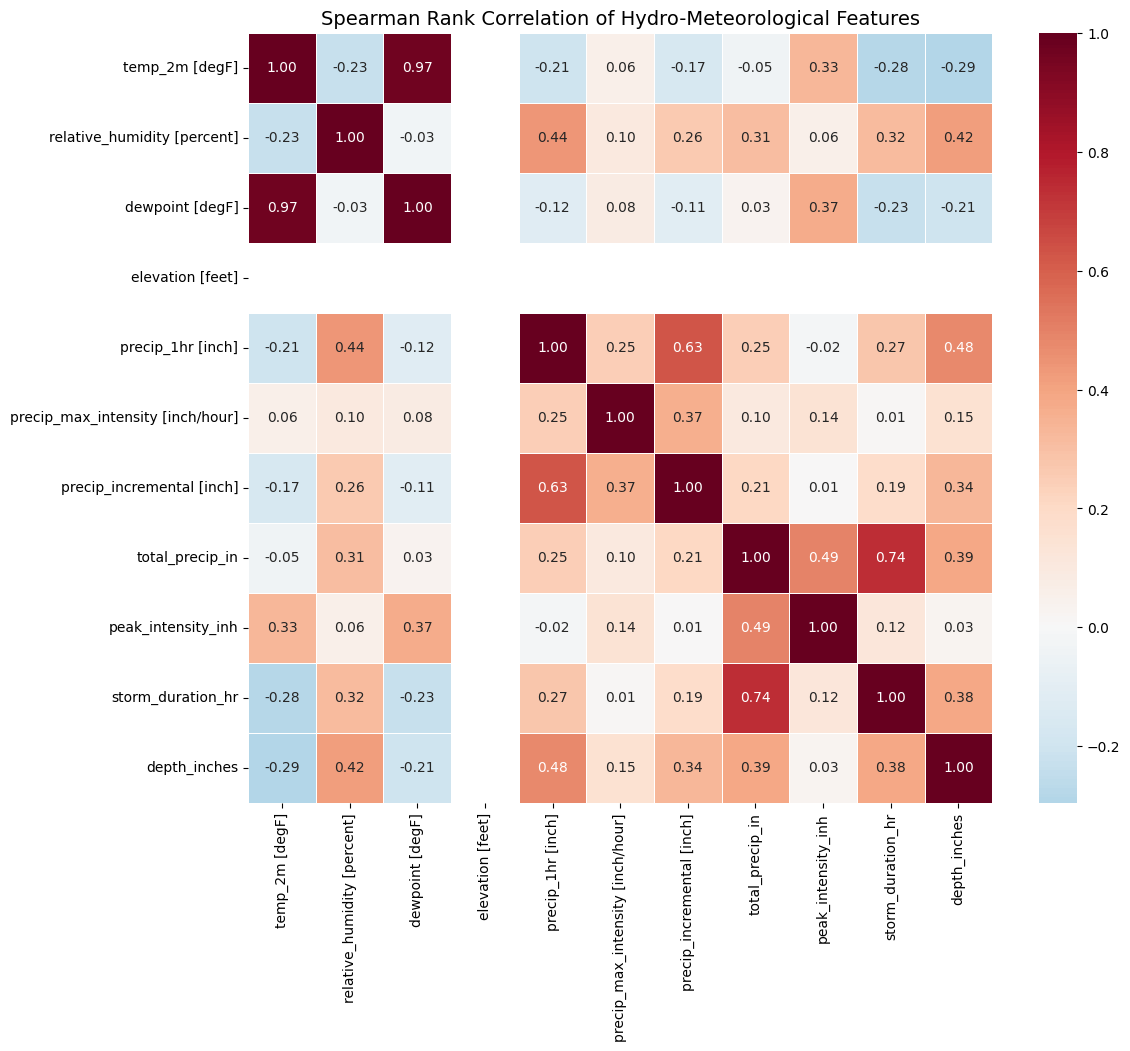

In [16]:
def plot_correlation_heatmap(df,features):
    # Calculate the correlation matrix
    corr_matrix = df[features].corr(method='spearman')

    plt.figure(figsize=(12, 10))
    sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt='.2f', linewidths=0.5)
    plt.title("Spearman Rank Correlation of Hydro-Meteorological Features", fontsize=14)
    plt.show()

plot_correlation_heatmap(df_storms,features)

In [17]:
def calculate_vif(df,features_to_test):    
    X = df[features_to_test].dropna()
    X = add_constant(X) # Add intercept for VIF calculation

    vif_data = pd.DataFrame()
    vif_data["Feature"] = X.columns
    vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]

    # Filter out the constant and sort
    return vif_data[vif_data["Feature"] != "const"].sort_values("VIF", ascending=False)

# Run the VIF test on the safe thermodynamic features
print(calculate_vif(df_storms,features))

                             Feature          VIF
3                   elevation [feet]  5070.649470
0                     temp_2m [degF]   960.697705
2                    dewpoint [degF]   933.858469
1        relative_humidity [percent]    72.103824
6          precip_incremental [inch]     5.655389
5   precip_max_intensity [inch/hour]     4.976786
7                    total_precip_in     3.520746
9                  storm_duration_hr     3.204932
4                  precip_1hr [inch]     1.579728
8                 peak_intensity_inh     1.469174
10                      depth_inches     1.310322


🔍 Found 18 safe numeric columns out of 47 total columns.

--- Variance Inflation Factor (VIF) ---
📊 Running VIF on 38875 complete rows...
                             Feature           VIF
1                      depth_proc_mm  1.501200e+15
2                       depth_inches  1.501200e+15
12           hours_since_storm_start  1.125900e+15
11            hours_since_rain_start  1.125900e+15
3                     temp_2m [degF]  1.049920e+03
5                    dewpoint [degF]  1.035269e+03
4        relative_humidity [percent]  7.962074e+01
18                 storm_duration_hr  1.603588e+01
17                storm_record_count  1.543034e+01
13                   total_precip_in  9.897564e+00
6          precip_incremental [inch]  5.779646e+00
15       intensity_hits_ge_threshold  5.488967e+00
7   precip_max_intensity [inch/hour]  5.073902e+00
14                peak_intensity_inh  3.434713e+00
16                 net_depth_rise_in  3.186369e+00
10                          storm_id  2.269278

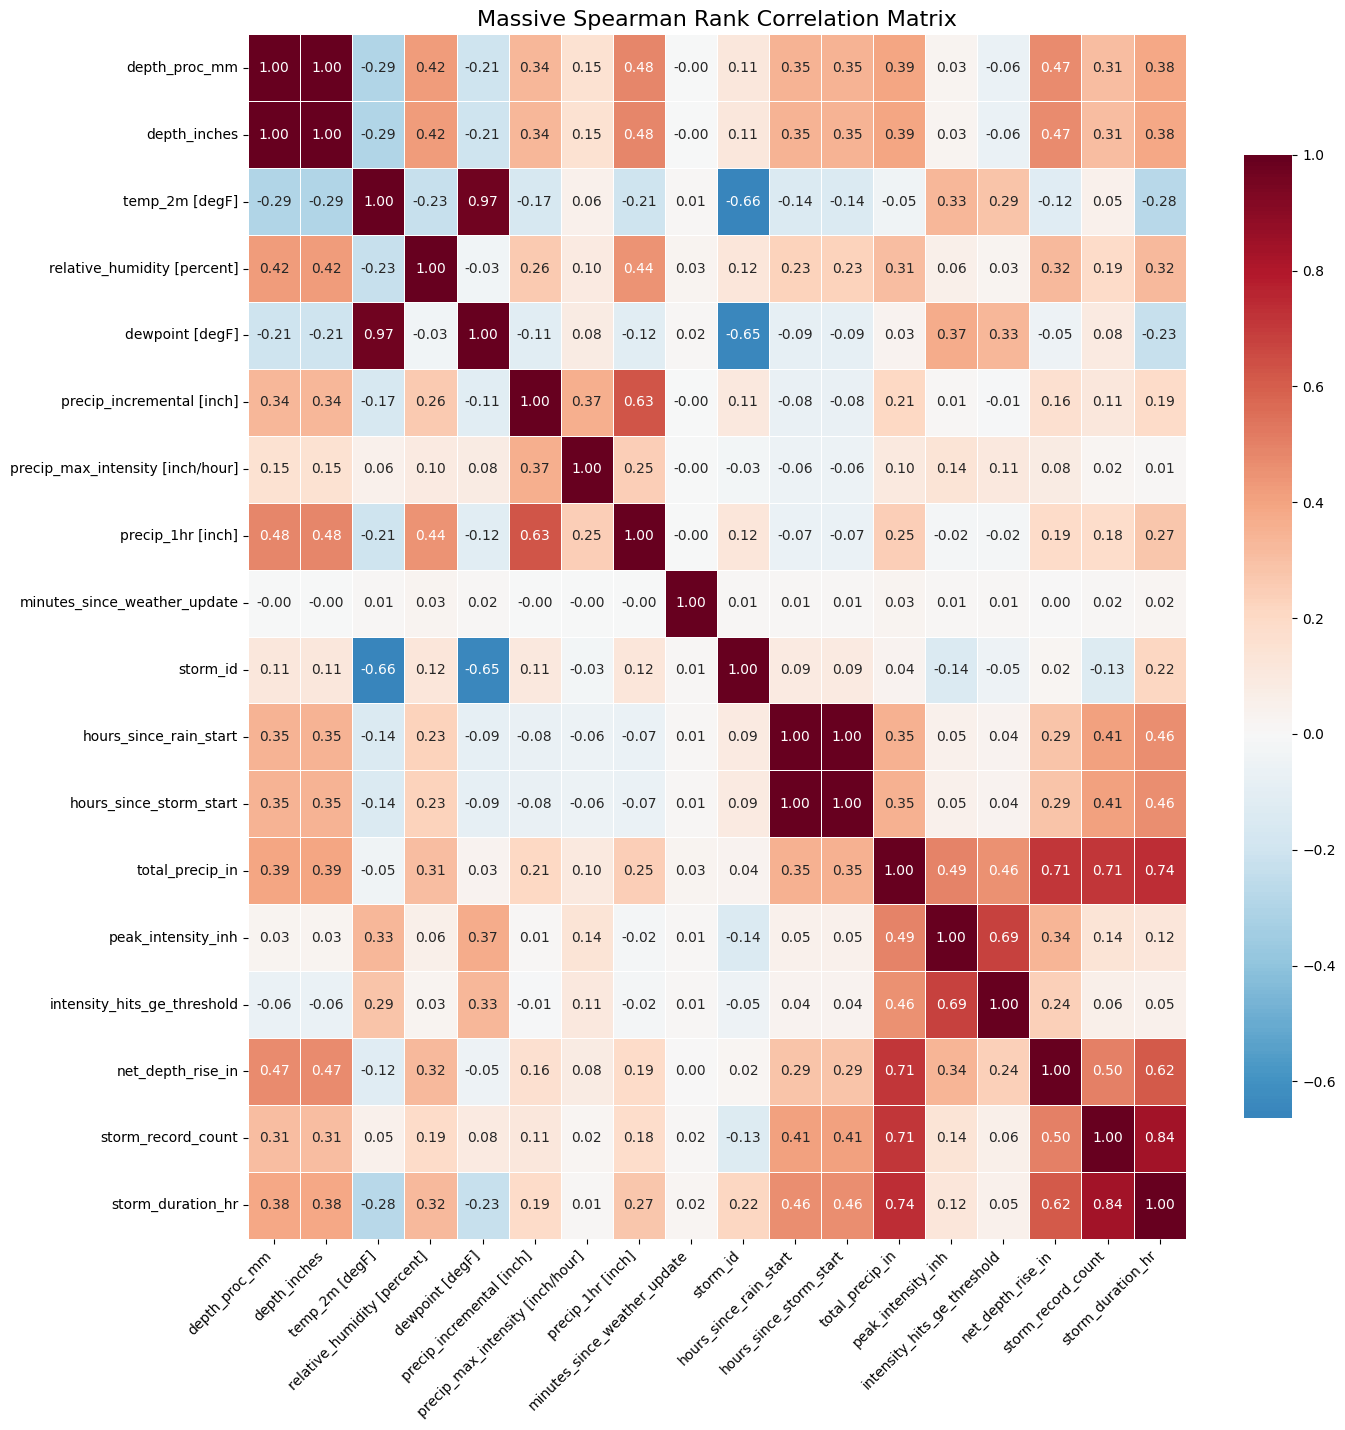

In [18]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.tools.tools import add_constant
from statsmodels.stats.outliers_influence import variance_inflation_factor

def get_safe_numeric_columns(df, max_missing_pct=0.10):
    """
    Automatically finds columns that are safe for VIF and Correlation.
    - Keeps only numeric columns.
    - Drops columns missing more than 10% of their data.
    - Drops columns with 0 variance (constants).
    """
    # 1. Get only numeric columns
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    
    safe_cols = []
    for col in numeric_cols:
        # 2. Check missing data threshold
        missing_pct = df[col].isna().mean()
        if missing_pct <= max_missing_pct:
            # 3. Ensure the column actually fluctuates (VIF breaks on constants)
            if df[col].std() > 0:
                safe_cols.append(col)
                
    print(f"🔍 Found {len(safe_cols)} safe numeric columns out of {len(df.columns)} total columns.")
    return safe_cols

def calculate_vif_robust(df, features):
    # Drop rows with NaNs only across the safe features
    X = df[features].dropna()
    print(f"📊 Running VIF on {len(X)} complete rows...")
    
    X = add_constant(X)
    vif_data = pd.DataFrame()
    vif_data["Feature"] = X.columns
    vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
    
    return vif_data[vif_data["Feature"] != "const"].sort_values("VIF", ascending=False)

def plot_massive_heatmap(df, features):
    # Calculate Spearman correlation
    corr_matrix = df[features].corr(method='spearman')
    
    # Dynamically scale the figure size based on how many columns we have
    fig_size = max(10, len(features) * 0.8)
    
    plt.figure(figsize=(fig_size, fig_size))
    sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt='.2f', 
                linewidths=0.5, cbar_kws={"shrink": .8})
    plt.title("Massive Spearman Rank Correlation Matrix", fontsize=16)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# --- EXECUTION ---

# 1. Automatically find all the good columns
all_safe_features = get_safe_numeric_columns(df_storms, max_missing_pct=0.10)

# 2. Run VIF
print("\n--- Variance Inflation Factor (VIF) ---")
vif_results = calculate_vif_robust(df_storms, all_safe_features)
print(vif_results)

# 3. Plot the giant Heatmap
print("\n--- Correlation Heatmap ---")
plot_massive_heatmap(df_storms, all_safe_features)

In [19]:
# 1. Final Pruned Feature List
selected_features = [
    'precip_1hr [inch]', 
    'precip_max_intensity [inch/hour]', 
    'temp_2m [degF]', 
    'soil_moisture_05cm [m^3/m^3]', 
    'elevation [feet]'
]

# 2. Target Variable
target = 'depth_inches'

# 3. Create the modeling dataframe (dropping NaNs and downcasting)
df_model = df_storms[selected_features + [target]].dropna()

for col in selected_features:
    df_model[col] = df_model[col].astype('float32')
    
print(f"Modeling dataset ready with {len(df_model):,} rows and {len(selected_features)} features.")

Modeling dataset ready with 0 rows and 5 features.


In [20]:
# Run the VIF test on the safe thermodynamic features
#print(calculate_vif(df_storms, thermo_features_safe))

# Run the Heatmap on the precipitation features
#plot_correlation_heatmap(df_storms, precip_features_safe)

## Hydrology Presentation Additions

These cells are designed to make the EDA notebook presentation-ready:
- clear hydrology narrative structure,
- event-based diagnostics,
- robustness checks, and
- export-ready figures.
        


### 1) Presentation Setup and Figure Style

Define a consistent plotting style and reusable settings for slide-quality output.
        


In [21]:
from pathlib import Path

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 13

PRESENTATION_GAP_MIN = 120
KEY_VARS = [
    'precip_1hr [inch]', 
    'precip_max_intensity [inch/hour]', 
    'precip_incremental [inch]',
    'total_precip_in',
    'temp_2m [degF]', 
    'relative_humidity [percent]', 
    'hours_since_storm_start',
    'storm_duration_hr',
    'peak_intensity_inh',
    'intensity_hits_ge_threshold'
]

print(f"Rows: {len(df_storms):,}")
print(f"Sensors: {df_storms['deployment_id'].nunique()}")
print(f"Time span: {df_storms['time'].min()} to {df_storms['time'].max()}")
        


Rows: 38,875
Sensors: 1
Time span: 2025-05-21 13:01:11.360000+00:00 to 2026-03-12 11:04:01.982000+00:00


### 2) Data QA/QC Dashboard

Show data completeness, record coverage, and median sensor timestep to document data reliability before interpretation.
        


,n_obs,start_time,end_time,median_depth,max_depth,record_days,missing_%_precip_1hr [inch],missing_%_precip_max_intensity [inch/hour],missing_%_precip_incremental [inch],missing_%_total_precip_in,missing_%_temp_2m [degF],missing_%_relative_humidity [percent],missing_%_hours_since_storm_start,missing_%_storm_duration_hr,missing_%_peak_intensity_inh,missing_%_intensity_hits_ge_threshold,median_timestep_min
deployment_id,,,,,,,,,,,,,,,,,
apparently-darling-gecko,38875,2025-05-21 13:01:11.360000+00:00,2026-03-12 11:04:01.982000+00:00,0.0,9.370079,294.918641,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.999367


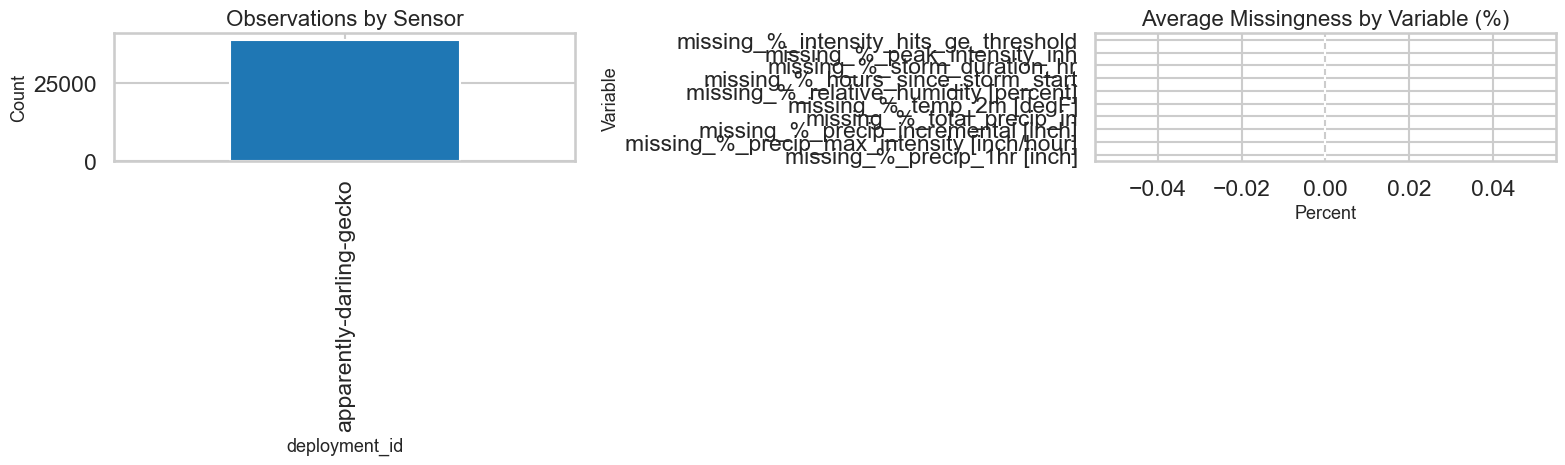

In [22]:
qaqc = (
    df_storms.sort_values(["deployment_id", "time"])
    .groupby("deployment_id")
    .agg(
        n_obs=("time", "size"),
        start_time=("time", "min"),
        end_time=("time", "max"),
        median_depth=("depth_inches", "median"),
        max_depth=("depth_inches", "max"),
    )
)

qaqc["record_days"] = (qaqc["end_time"] - qaqc["start_time"]).dt.total_seconds() / 86400

missing_pct = (
    df_storms.groupby("deployment_id")[KEY_VARS]
    .apply(lambda x: x.isna().mean() * 100)
    .add_prefix("missing_%_")
)

qaqc = qaqc.join(missing_pct)

median_step_min = (
    df_storms.sort_values(["deployment_id", "time"]) 
    .groupby("deployment_id")["time"]
    .diff()
    .dt.total_seconds()
    .div(60)
)
qaqc["median_timestep_min"] = median_step_min.groupby(df_storms["deployment_id"]).median().values

display(qaqc.sort_values("n_obs", ascending=False).head(10))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
qaqc["n_obs"].sort_values(ascending=False).plot(kind="bar", ax=axes[0], color="#1f77b4")
axes[0].set_title("Observations by Sensor")
axes[0].set_xlabel("deployment_id")
axes[0].set_ylabel("Count")

qaqc.filter(like="missing_%_").mean().sort_values().plot(kind="barh", ax=axes[1], color="#d62728")
axes[1].set_title("Average Missingness by Variable (%)")
axes[1].set_xlabel("Percent")
axes[1].set_ylabel("Variable")

plt.tight_layout()
plt.show()
        


### 3) Event Signatures (Hydrology Core Table)

Create event-level hydrologic signatures per sensor:
- event duration,
- total precipitation,
- peak depth,
- lag-to-peak, and
- response ratio (peak depth / total precip).
        


In [23]:
def build_event_signatures(df, gap_minutes=120):
    required = [
    'deployment_id',
    'time',
    'precip_1hr [inch]', 
    'precip_max_intensity [inch/hour]', 
    'precip_incremental [inch]',
    'total_precip_in',
    'temp_2m [degF]', 
    'relative_humidity [percent]', 
    'hours_since_storm_start',
    'storm_duration_hr',
    'peak_intensity_inh',
    'intensity_hits_ge_threshold',
    'depth_inches',
    'elevation [feet]', 
    'latitude', 
    'longitude'
]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    data = df[required].copy().sort_values(["deployment_id", "time"])
    data["time_diff_min"] = (
        data.groupby("deployment_id")["time"].diff().dt.total_seconds() / 60
    )
    data["new_event"] = data["time_diff_min"].isna() | (data["time_diff_min"] > gap_minutes)
    data["event_id"] = data.groupby("deployment_id")["new_event"].cumsum().astype(int)

    grouped = data.groupby(["deployment_id", "event_id"], as_index=False)
    events = grouped.agg(
        event_start=("time", "min"),
        event_end=("time", "max"),
        n_points=("time", "size"),
        total_precip=("precip_1hr [inch]", "sum"),
        peak_depth=("depth_inches", "max"),
        elevation_ft=("elevation [feet]", "first"),
        latitude=("latitude", "first"),
        longitude=("longitude", "first"),
    )

    peak_times = (
        data.sort_values("depth_inches", ascending=False)
        .groupby(["deployment_id", "event_id"], as_index=False)
        .first()[["deployment_id", "event_id", "time"]]
        .rename(columns={"time": "peak_time"})
    )
    events = events.merge(peak_times, on=["deployment_id", "event_id"], how="left")

    events["duration_hr"] = (events["event_end"] - events["event_start"]).dt.total_seconds() / 3600
    events["lag_to_peak_min"] = (events["peak_time"] - events["event_start"]).dt.total_seconds() / 60
    events["response_ratio"] = np.where(events["total_precip"] > 0, events["peak_depth"] / events["total_precip"], np.nan)

    # Keep hydrologically meaningful rainfall events.
    events = events[(events["total_precip"] > 0) & (events["n_points"] >= 3)].copy()
    return events.sort_values(["deployment_id", "event_start"]).reset_index(drop=True)


events_120 = build_event_signatures(df_storms, gap_minutes=PRESENTATION_GAP_MIN)
print(f"Event rows: {len(events_120):,}")
display(events_120.head(10))

events_120[["total_precip", "peak_depth", "duration_hr", "lag_to_peak_min", "response_ratio"]].describe().T
        


Event rows: 63


,deployment_id,event_id,event_start,event_end,n_points,total_precip,peak_depth,elevation_ft,latitude,longitude,peak_time,duration_hr,lag_to_peak_min,response_ratio
0,apparently-darling-gecko,1,2025-05-21 13:01:11.360000+00:00,2025-05-21 21:03:20.284000+00:00,481,0.198083,0.000000,82,40.883259,-73.905853,2025-05-21 13:01:11.360000+00:00,8.035812,0.000000,0.000000
1,apparently-darling-gecko,2,2025-05-22 03:45:43.888000+00:00,2025-05-22 18:58:54.650000+00:00,915,3.281250,1.299213,82,40.883259,-73.905853,2025-05-22 09:34:32.603000+00:00,15.219656,348.811917,0.395950
2,apparently-darling-gecko,3,2025-05-23 21:11:00.745000+00:00,2025-05-24 07:13:47.347000+00:00,604,1.006667,1.259843,82,40.883259,-73.905853,2025-05-24 01:25:59.496000+00:00,10.046278,254.979183,1.251499
3,apparently-darling-gecko,4,2025-05-28 21:15:49.456000+00:00,2025-05-29 17:23:28.887000+00:00,1158,3.039667,1.259843,82,40.883259,-73.905853,2025-05-29 02:27:11.270000+00:00,20.127620,311.363567,0.414467
4,apparently-darling-gecko,5,2025-05-31 03:46:49.328000+00:00,2025-05-31 12:34:10.487000+00:00,528,1.719250,1.377953,82,40.883259,-73.905853,2025-05-31 06:27:45.602000+00:00,8.789211,160.937900,0.801485
5,apparently-darling-gecko,6,2025-06-06 20:06:26.412000+00:00,2025-06-07 04:14:25.318000+00:00,468,0.123917,0.000000,82,40.883259,-73.905853,2025-06-07 01:31:25.331000+00:00,8.133029,324.981983,0.000000
6,apparently-darling-gecko,7,2025-06-07 15:56:23.351000+00:00,2025-06-08 04:34:22.321000+00:00,736,1.466833,1.496063,82,40.883259,-73.905853,2025-06-07 18:20:23.285000+00:00,12.633047,143.998900,1.019927
7,apparently-darling-gecko,8,2025-06-09 13:15:17.236000+00:00,2025-06-09 21:19:16.207000+00:00,484,0.145667,0.000000,82,40.883259,-73.905853,2025-06-09 14:15:17.217000+00:00,8.066381,59.999683,0.000000
8,apparently-darling-gecko,9,2025-06-10 08:36:15.204000+00:00,2025-06-10 22:29:13.172000+00:00,817,2.718750,1.614173,82,40.883259,-73.905853,2025-06-10 14:37:14.138000+00:00,13.882769,360.982233,0.593719
9,apparently-darling-gecko,10,2025-06-14 12:46:01.985000+00:00,2025-06-14 22:53:00.892000+00:00,608,0.698750,0.000000,82,40.883259,-73.905853,2025-06-14 22:53:00.892000+00:00,10.116363,606.981783,0.000000


,count,mean,std,min,25%,50%,75%,max
total_precip,63.0,1.855632,2.423190,0.005000,0.455333,0.987333,2.128542,11.378250
peak_depth,63.0,1.039870,1.407528,0.000000,0.216535,0.984252,1.299213,9.370079
duration_hr,63.0,12.014714,5.920565,0.050023,8.549707,10.116363,13.507773,32.798865
lag_to_peak_min,63.0,368.497660,257.810768,0.000000,166.500025,311.363567,479.982825,1118.966250
response_ratio,63.0,4.339123,27.697266,0.000000,0.068147,0.508214,1.139307,220.472443


### 5) Event Definition Sensitivity (60/120/180 min)

Check how inter-event threshold selection affects event counts and key signatures.
        


,gap_min,n_events,median_total_precip,median_peak_depth,median_lag_to_peak_min,median_response_ratio
0,60,65,0.987333,0.984252,304.983350,0.508214
1,120,63,0.987333,0.984252,311.363567,0.508214
2,180,62,0.994458,1.003937,324.991217,0.467035


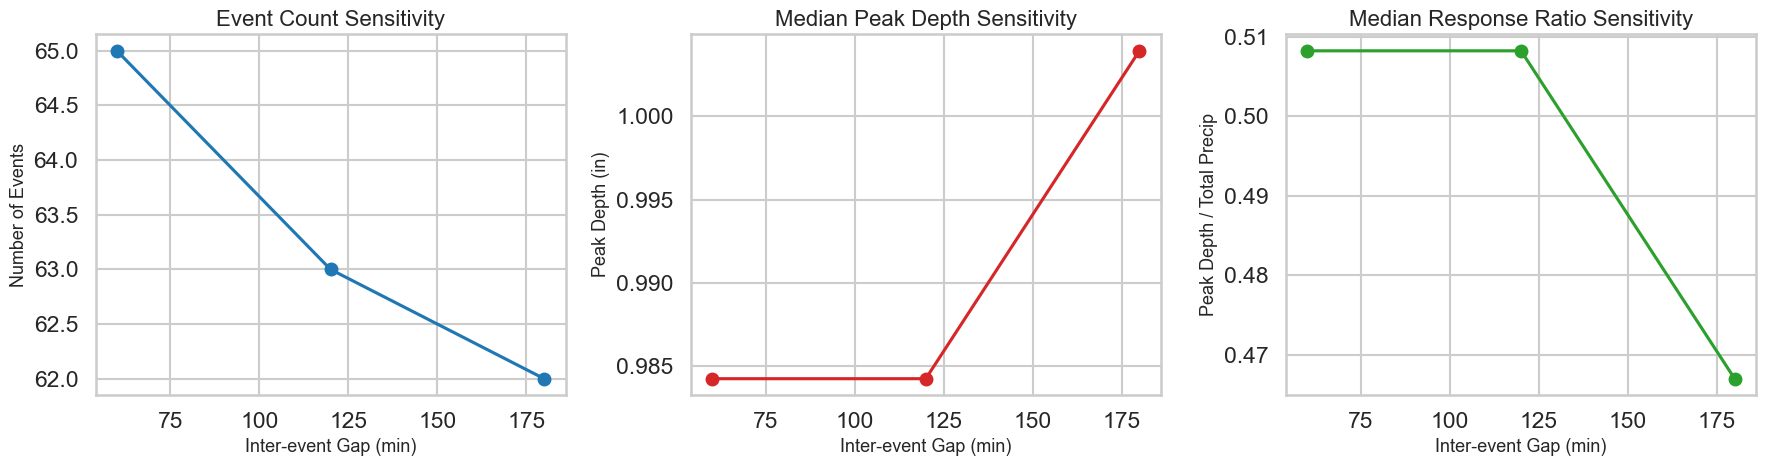

In [24]:
sensitivity_rows = []
for gap in [60, 120, 180]:
    ev = build_event_signatures(df_storms, gap_minutes=gap)
    sensitivity_rows.append(
        {
            "gap_min": gap,
            "n_events": len(ev),
            "median_total_precip": ev["total_precip"].median(),
            "median_peak_depth": ev["peak_depth"].median(),
            "median_lag_to_peak_min": ev["lag_to_peak_min"].median(),
            "median_response_ratio": ev["response_ratio"].median(),
        }
    )

sensitivity_df = pd.DataFrame(sensitivity_rows)
display(sensitivity_df)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(sensitivity_df["gap_min"], sensitivity_df["n_events"], marker="o", color="#1f77b4")
axes[0].set_title("Event Count Sensitivity")
axes[0].set_xlabel("Inter-event Gap (min)")
axes[0].set_ylabel("Number of Events")

axes[1].plot(sensitivity_df["gap_min"], sensitivity_df["median_peak_depth"], marker="o", color="#d62728")
axes[1].set_title("Median Peak Depth Sensitivity")
axes[1].set_xlabel("Inter-event Gap (min)")
axes[1].set_ylabel("Peak Depth (in)")

axes[2].plot(sensitivity_df["gap_min"], sensitivity_df["median_response_ratio"], marker="o", color="#2ca02c")
axes[2].set_title("Median Response Ratio Sensitivity")
axes[2].set_xlabel("Inter-event Gap (min)")
axes[2].set_ylabel("Peak Depth / Total Precip")

plt.tight_layout()
plt.show()
        


### 6) Exceedance and Frequency Context

Show empirical exceedance behavior of event peak depths to communicate risk context.
        


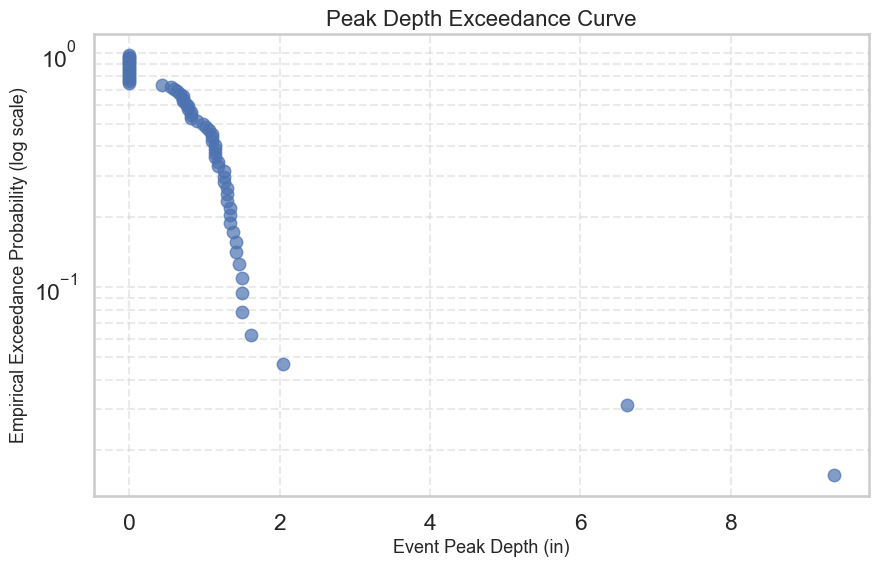

In [25]:
ex = events_120[["peak_depth"]].dropna().sort_values("peak_depth", ascending=False).reset_index(drop=True)
ex["rank"] = np.arange(1, len(ex) + 1)
ex["exceedance_prob"] = ex["rank"] / (len(ex) + 1)

plt.figure(figsize=(10, 6))
plt.plot(ex["peak_depth"], ex["exceedance_prob"], marker="o", linestyle="none", alpha=0.7)
plt.yscale("log")
plt.xlabel("Event Peak Depth (in)")
plt.ylabel("Empirical Exceedance Probability (log scale)")
plt.title("Peak Depth Exceedance Curve")
plt.grid(True, which="both", linestyle="--", alpha=0.4)
plt.show()
        


### 7) Spatial Variability Summary

Aggregate event signatures by sensor and compare hydrologic response across space and elevation.
        


,deployment_id,n_events,median_peak_depth,median_response_ratio,median_lag_to_peak,elevation_ft,latitude,longitude
0,apparently-darling-gecko,63,0.984252,0.508214,311.363567,82,40.883259,-73.905853


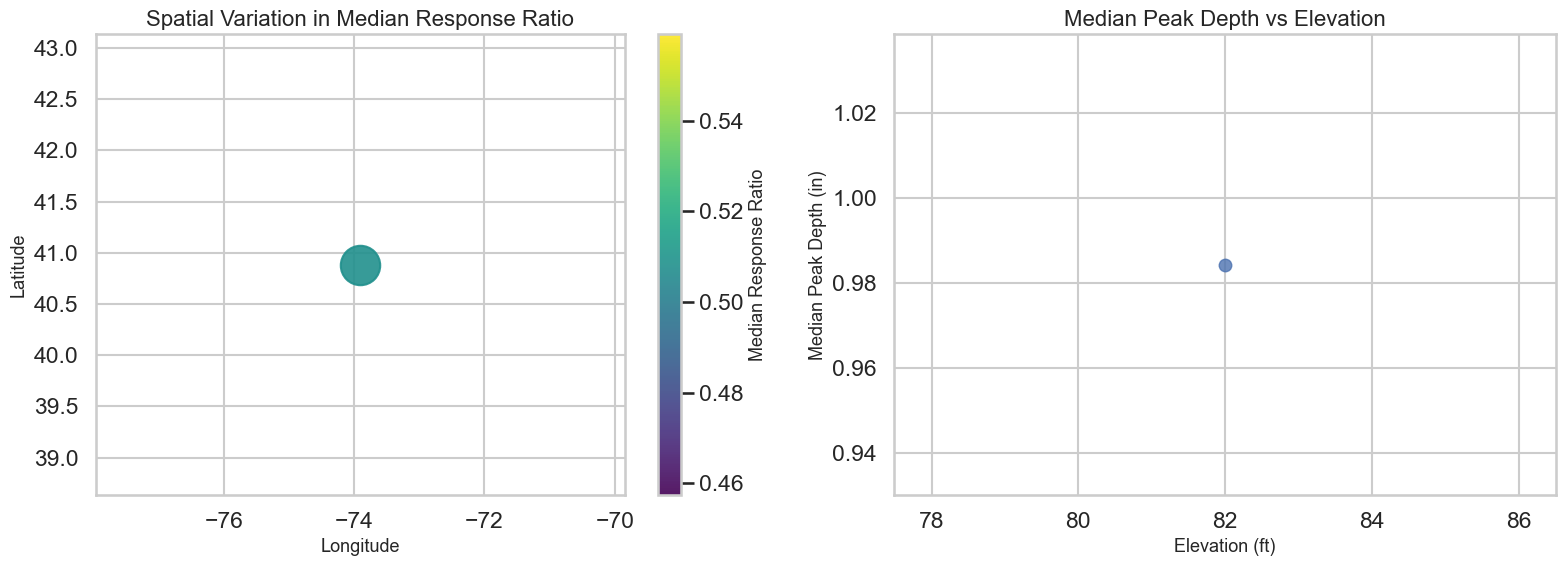

In [26]:
sensor_event_summary = events_120.groupby("deployment_id", as_index=False).agg(
    n_events=("event_id", "size"),
    median_peak_depth=("peak_depth", "median"),
    median_response_ratio=("response_ratio", "median"),
    median_lag_to_peak=("lag_to_peak_min", "median"),
    elevation_ft=("elevation_ft", "first"),
    latitude=("latitude", "first"),
    longitude=("longitude", "first"),
)

display(sensor_event_summary.sort_values("median_peak_depth", ascending=False).head(10))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sc = axes[0].scatter(
    sensor_event_summary["longitude"],
    sensor_event_summary["latitude"],
    c=sensor_event_summary["median_response_ratio"],
    s=50 + 12 * sensor_event_summary["n_events"],
    cmap="viridis",
    alpha=0.9,
)
axes[0].set_title("Spatial Variation in Median Response Ratio")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")
plt.colorbar(sc, ax=axes[0], label="Median Response Ratio")

sns.regplot(
    data=sensor_event_summary,
    x="elevation_ft",
    y="median_peak_depth",
    ax=axes[1],
    scatter_kws={"alpha": 0.8},
    line_kws={"color": "black", "lw": 2},
)
axes[1].set_title("Median Peak Depth vs Elevation")
axes[1].set_xlabel("Elevation (ft)")
axes[1].set_ylabel("Median Peak Depth (in)")

plt.tight_layout()
plt.show()
        


### 8) Slide-Ready Figure Export

Use these helpers to consistently export figures for your deck.
        


In [27]:
EXPORT_DIR = Path("results/presentation_figures")
EXPORT_DIR.mkdir(parents=True, exist_ok=True)


def export_current_figure(name, dpi=300):
    file_name = "".join(ch if ch.isalnum() or ch in ["_", "-"] else "_" for ch in name.strip().lower())
    out_path = EXPORT_DIR / f"{file_name}.png"
    plt.gcf().savefig(out_path, dpi=dpi, bbox_inches="tight", facecolor="white")
    print(f"Saved: {out_path}")


print(f"Export directory: {EXPORT_DIR.resolve()}")
print("After creating any figure, run: export_current_figure('figure_name')")
        


Export directory: /sfs/gpfs/tardis/home/dng3fe/floodnet_work/Finalized_Scripts/results/presentation_figures
After creating any figure, run: export_current_figure('figure_name')


## Additional Graph Types for Presentation

These plots add alternative visual perspectives often expected in hydrology talks: density, seasonality, distribution shape, and sensor ranking.
    


### 9) Event Response Density (Hexbin)

Visualize nonlinear response between event rainfall and peak flood depth.
    


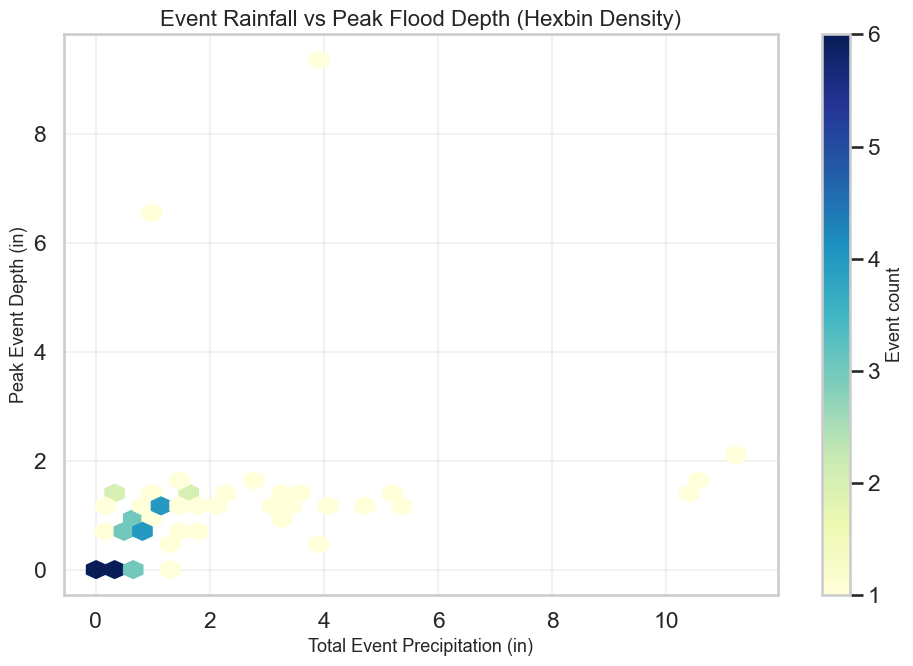

In [28]:
if "events_120" not in globals():
    if "build_event_signatures" in globals():
        events_120 = build_event_signatures(df_storms, gap_minutes=120)
    else:
        raise NameError("events_120 not found and build_event_signatures is not defined.")

hex_df = events_120.dropna(subset=["total_precip", "peak_depth"]).copy()
hex_df = hex_df[(hex_df["total_precip"] > 0) & (hex_df["peak_depth"] >= 0)]

plt.figure(figsize=(10, 7))
plt.hexbin(
    hex_df["total_precip"],
    hex_df["peak_depth"],
    gridsize=35,
    cmap="YlGnBu",
    mincnt=1,
)
cb = plt.colorbar()
cb.set_label("Event count")
plt.xlabel("Total Event Precipitation (in)")
plt.ylabel("Peak Event Depth (in)")
plt.title("Event Rainfall vs Peak Flood Depth (Hexbin Density)")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()
    


### 12) Diurnal Flood Depth Distribution (Violin)

Summarize depth distributions by hour-of-day to inspect diurnal structure in observed water levels.
    


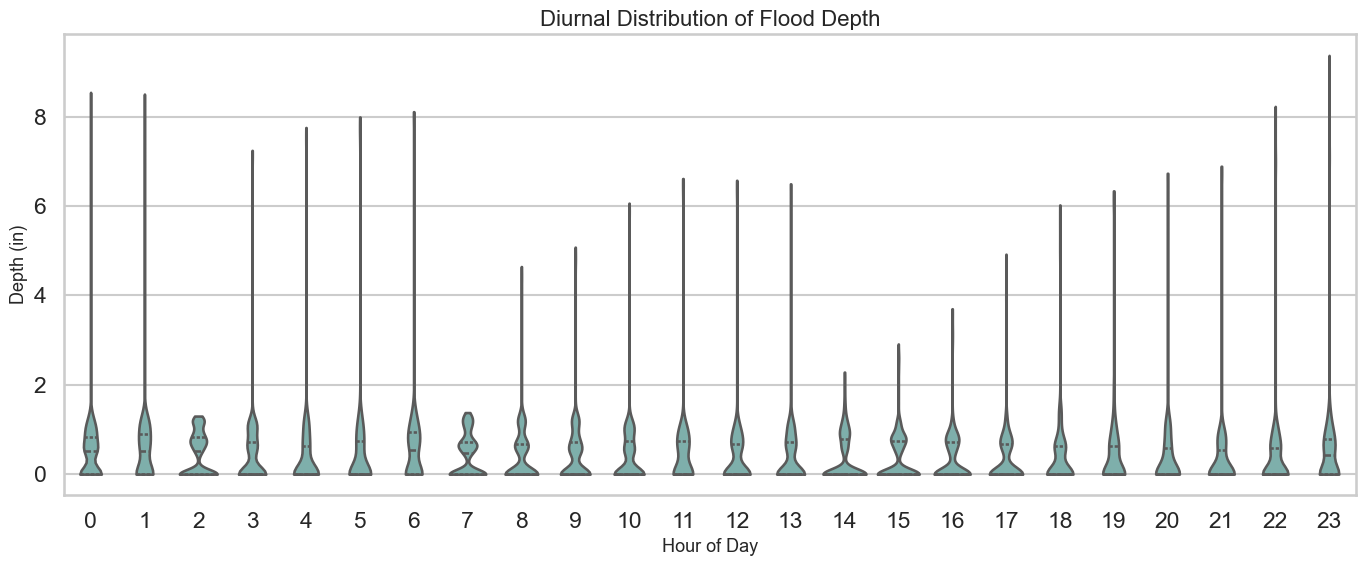

In [29]:
diurnal = df_storms.dropna(subset=["time", "depth_inches"]).copy()
diurnal["hour"] = diurnal["time"].dt.hour

# Optional light sampling for very large datasets to keep plotting responsive.
max_rows = 200000
if len(diurnal) > max_rows:
    diurnal = diurnal.sample(max_rows, random_state=42)

plt.figure(figsize=(14, 6))
sns.violinplot(data=diurnal, x="hour", y="depth_inches", inner="quartile", cut=0, color="#76b7b2")
plt.title("Diurnal Distribution of Flood Depth")
plt.xlabel("Hour of Day")
plt.ylabel("Depth (in)")
plt.tight_layout()
plt.show()
    


### 14) Sensor Ranking (Lollipop)

Rank sensors by median event peak depth for a concise spatial performance narrative.
    


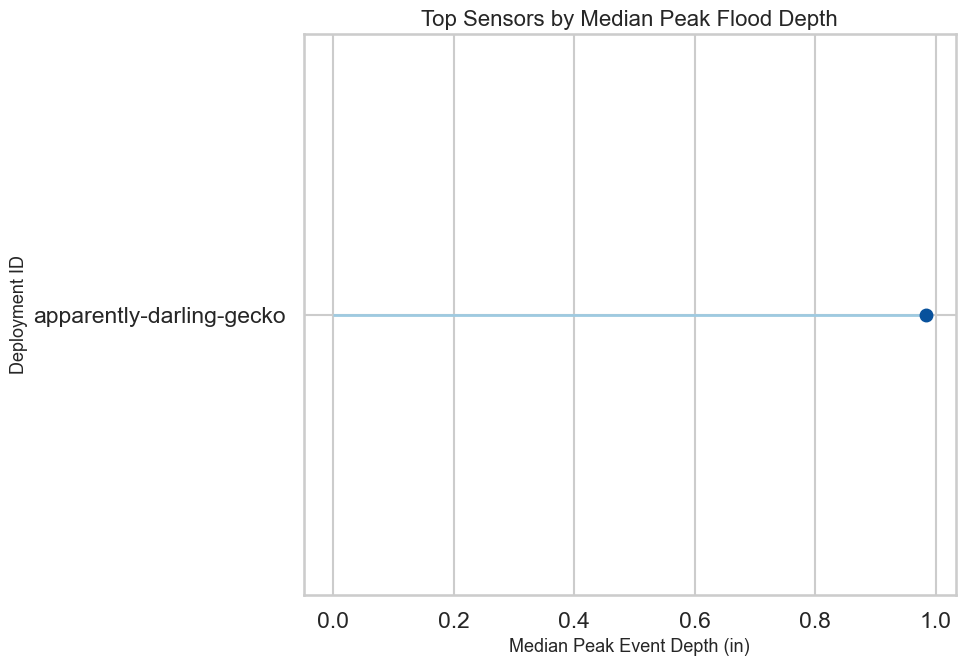

In [30]:
if "sensor_event_summary" not in globals():
    sensor_event_summary = events_120.groupby("deployment_id", as_index=False).agg(
        n_events=("event_id", "size"),
        median_peak_depth=("peak_depth", "median"),
    )

rank_df = sensor_event_summary.dropna(subset=["median_peak_depth"]).copy()
rank_df = rank_df.sort_values("median_peak_depth", ascending=False).head(15)
rank_df = rank_df.sort_values("median_peak_depth")

plt.figure(figsize=(10, 7))
plt.hlines(y=rank_df["deployment_id"], xmin=0, xmax=rank_df["median_peak_depth"], color="#9ecae1", linewidth=2)
plt.plot(rank_df["median_peak_depth"], rank_df["deployment_id"], "o", color="#08519c")
plt.xlabel("Median Peak Event Depth (in)")
plt.ylabel("Deployment ID")
plt.title("Top Sensors by Median Peak Flood Depth")
plt.tight_layout()
plt.show()
    
